# Import the required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import math 
import statistics as st
import scipy.stats as sts
from scipy.stats import norm
from scipy.stats import t
from scipy.stats import f_oneway

from scipy.stats import skew,norm,kurtosis
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn import neighbors
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

### Test Data 

In [4]:
test_df = pd.read_excel('test data.xlsx')
test_df.columns

Index(['Unnamed: 0', 'appearance_id', 'game_id', 'player_id', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played',
       'season', 'round', 'home_club_goals', 'away_club_goals',
       'home_club_position', 'away_club_position', 'home_club_manager_name',
       'away_club_manager_name', 'stadium', 'attendance', 'referee',
       'home_club_name', 'away_club_name', 'aggregate', 'competition_type',
       'game_event_id', 'date', 'minute', 'type_x', 'player_in_id', 'name',
       'last_season', 'current_club_id', 'player_code', 'country_of_birth',
       'date_of_birth', 'sub_position', 'position_x', 'foot', 'height_in_cm',
       'market_value_in_eur', 'highest_market_value_in_eur',
       'contract_expiration_date', 'game_lineups_id', 'type_y', 'number',
       'player_name', 'team_captain', 'position_y'],
      dtype='object')

## Read the  dataset 

In [6]:
football_df = pd.read_csv('Football_data_merged_cleaned1.csv')
football_df

,appearance_id,player_id,yellow_cards,red_cards,goals,assists,minutes_played,season,round,home_club_goals,...,market_value_in_eur,highest_market_value_in_eur,contract_expiration_date,game_lineups_id,player_role,number,team_captain,player_sub_position,player_name,game_id
0,2231426_49723,49723,0,0,0,0,70,2012,4. Matchday,1,...,700000.0,5000000.0,2025-06-30 00:00:00,8d717b1017e72d89d2ee1112bb2d7466,substitutes,22,0,Right-Back,Timothy Chandler,2231426
1,2231426_49723,49723,0,0,0,0,70,2012,4. Matchday,1,...,700000.0,5000000.0,2025-06-30 00:00:00,d53eb3fd74523d6dd4536653c145ae96,substitutes,22,0,Right-Back,Timothy Chandler,2231426
2,2231426_49723,49723,0,0,0,0,70,2012,4. Matchday,1,...,700000.0,5000000.0,2025-06-30 00:00:00,3efc21c645e46b2f411bcdb1710aa444,substitutes,22,0,Right-Back,Timothy Chandler,2231426
3,2231426_49723,49723,0,0,0,0,70,2012,4. Matchday,1,...,700000.0,5000000.0,2025-06-30 00:00:00,cc79e78c570ce19872dfed125d324407,substitutes,22,0,Right-Back,Timothy Chandler,2231426
4,2231426_49723,49723,0,0,0,0,70,2012,4. Matchday,1,...,700000.0,5000000.0,2025-06-30 00:00:00,21de58902f547e231bf2604be9fa996f,substitutes,22,0,Right-Back,Timothy Chandler,2231426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3632,3415291_537467,537467,0,0,1,0,77,2020,7. Matchday,3,...,300000.0,600000.0,2026-06-30,26085977dac1dc934abb39888f128636,substitutes,11,0,Centre-Forward,Joseph Efford,3415291
3633,3415291_537467,537467,0,0,1,0,77,2020,7. Matchday,3,...,300000.0,600000.0,2026-06-30,eadce2f0ce9f400d0561a8c05453d702,substitutes,28,0,Centre-Forward,Joseph Efford,3415291
3634,3415291_537467,537467,0,0,1,0,77,2020,7. Matchday,3,...,300000.0,600000.0,2026-06-30,bc79183aa9a1ffacb14cc733f6143411,substitutes,28,0,Centre-Forward,Joseph Efford,3415291
3635,3415291_537467,537467,0,0,1,0,77,2020,7. Matchday,3,...,300000.0,600000.0,2026-06-30,e16817800f83daf7bad1ddabf58316b7,substitutes,28,0,Centre-Forward,Joseph Efford,3415291


### Coverting the cleanded data into excel to perform the visualisation in tableau

In [8]:
football_df.to_excel('Football_data_final.xlsx',index = False)

## Checking null values 

In [10]:
football_df.isnull().sum()

appearance_id                  0
player_id                      0
yellow_cards                   0
red_cards                      0
goals                          0
assists                        0
minutes_played                 0
season                         0
round                          0
home_club_goals                0
away_club_goals                0
home_club_position             0
away_club_position             0
home_club_manager_name         0
away_club_manager_name         0
stadium                        0
attendance                     0
referee                        0
home_club_name                 0
away_club_name                 0
aggregate                      0
competition_type               0
game_event_id                  0
date                           0
minute                         0
event_type                     0
player_in_id                   0
player_assist_id               0
name                           0
last_season                    0
current_cl

### Dataset information 

In [12]:
football_df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3637 entries, 0 to 3636
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   appearance_id                3637 non-null   object 
 1   player_id                    3637 non-null   int64  
 2   yellow_cards                 3637 non-null   int64  
 3   red_cards                    3637 non-null   int64  
 4   goals                        3637 non-null   int64  
 5   assists                      3637 non-null   int64  
 6   minutes_played               3637 non-null   int64  
 7   season                       3637 non-null   int64  
 8   round                        3637 non-null   object 
 9   home_club_goals              3637 non-null   int64  
 10  away_club_goals              3637 non-null   int64  
 11  home_club_position           3637 non-null   float64
 12  away_club_position           3637 non-null   float64
 13  home_club_manager_

### Displaying the columns

In [14]:
football_df.columns.sort_values(ascending  = True)

Index(['aggregate', 'appearance_id', 'assists', 'attendance',
       'away_club_goals', 'away_club_manager_name', 'away_club_name',
       'away_club_position', 'competition_type', 'contract_expiration_date',
       'country_of_birth', 'current_club_id', 'date', 'date_of_birth',
       'event_type', 'foot', 'game_event_id', 'game_id', 'game_lineups_id',
       'goals', 'height_in_cm', 'highest_market_value_in_eur',
       'home_club_goals', 'home_club_manager_name', 'home_club_name',
       'home_club_position', 'last_season', 'market_value_in_eur', 'minute',
       'minutes_played', 'name', 'number', 'player_assist_id', 'player_code',
       'player_id', 'player_in_id', 'player_name', 'player_role',
       'player_sub_position', 'position', 'red_cards', 'referee', 'round',
       'season', 'stadium', 'sub_position', 'team_captain', 'yellow_cards'],
      dtype='object')

### Showing the total number of rows and columns 

In [16]:
print("Number of rows :",football_df.shape[0])
print("Number of columns :",football_df.shape[1])      

Number of rows : 3637
Number of columns : 48


### Checking the duplicates values 

In [18]:
football_df.duplicated().sum()

0

In [19]:
numerical = football_df.select_dtypes(exclude = 'object')
numerical

,player_id,yellow_cards,red_cards,goals,assists,minutes_played,season,home_club_goals,away_club_goals,home_club_position,...,player_in_id,player_assist_id,last_season,current_club_id,height_in_cm,market_value_in_eur,highest_market_value_in_eur,number,team_captain,game_id
0,49723,0,0,0,0,70,2012,1,2,6.0,...,60957.0,16893.185486,2023,24,186.0,700000.0,5000000.0,22,0,2231426
1,49723,0,0,0,0,70,2012,1,2,6.0,...,60957.0,16893.185486,2023,24,186.0,700000.0,5000000.0,22,0,2231426
2,49723,0,0,0,0,70,2012,1,2,6.0,...,60957.0,16893.185486,2023,24,186.0,700000.0,5000000.0,22,0,2231426
3,49723,0,0,0,0,70,2012,1,2,6.0,...,60957.0,16893.185486,2023,24,186.0,700000.0,5000000.0,22,0,2231426
4,49723,0,0,0,0,70,2012,1,2,6.0,...,60957.0,16893.185486,2023,24,186.0,700000.0,5000000.0,22,0,2231426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3632,537467,0,0,1,0,77,2020,3,2,3.0,...,358907.0,16474.000000,2023,2671,176.0,300000.0,600000.0,11,0,3415291
3633,537467,0,0,1,0,77,2020,3,2,3.0,...,358907.0,16474.000000,2023,2671,176.0,300000.0,600000.0,28,0,3415291
3634,537467,0,0,1,0,77,2020,3,2,3.0,...,358907.0,16474.000000,2023,2671,176.0,300000.0,600000.0,28,0,3415291
3635,537467,0,0,1,0,77,2020,3,2,3.0,...,358907.0,16474.000000,2023,2671,176.0,300000.0,600000.0,28,0,3415291


#### Outliers Treatment using winsorization technique.

In [21]:
"""" def iqr_winsorzation (df,thersh = 1.5):
    df_out = df.copy()
    columns_to_treat = ['highest_market_value_in_eur','market_value_in_eur']
    for col in columns_to_treat:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - thersh * IQR
        upper_fence = Q3 + thersh * IQR

        df_out.loc[df_out[col] < lower_fence, col] = lower_fence
            df_out.loc[df_out[col] > upper_fence, col] = 1`

    return df_out
    
treated_df = iqr_winsorzation(numerical.copy()) # it ensures that the original dataframe is not altered 
# print original and capped DataFrame 

treated_df """

'" def iqr_winsorzation (df,thersh = 1.5):\n    df_out = df.copy()\n    columns_to_treat = [\'highest_market_value_in_eur\',\'market_value_in_eur\']\n    for col in columns_to_treat:\n        Q1 = df_out[col].quantile(0.25)\n        Q3 = df_out[col].quantile(0.75)\n        IQR = Q3 - Q1\n        lower_fence = Q1 - thersh * IQR\n        upper_fence = Q3 + thersh * IQR\n\n        df_out.loc[df_out[col] < lower_fence, col] = lower_fence\n            df_out.loc[df_out[col] > upper_fence, col] = 1`\n\n    return df_out\n    \ntreated_df = iqr_winsorzation(numerical.copy()) # it ensures that the original dataframe is not altered \n# print original and capped DataFrame \n\ntreated_df '

In [22]:
# outlier visual through boxplot 
'''' sns.boxplot(data = treated_df[['highest_market_value_in_eur','market_value_in_eur']])
plt.gcf().set_size_inches(20,6)
plt.show() ''' 

"' sns.boxplot(data = treated_df[['highest_market_value_in_eur','market_value_in_eur']])\nplt.gcf().set_size_inches(20,6)\nplt.show() "

##### connect the file to sql database 

In [24]:
#pip install mysql-connector-python

In [25]:
'''
!pip install ipykernal
!pip install pymysql
import pymysql as py
'''

'\n!pip install ipykernal\n!pip install pymysql\nimport pymysql\xa0as\xa0py\n'

In [26]:
#import mysql.connector as py

In [27]:
#db =py.connect(host="localhost",user="root",password="GuruRahul123",database="gr_capstone")
#mycursor=db.cursor()

In [28]:
#mycursor.execute("select VERSION()")

In [29]:
#mycursor.fetchone()

In [30]:
#from sqlalchemy import create_engine

In [31]:
#engine=create_engine("mysql+pymysql://{user}:{pw}@{host}/{db}".format(host='localhost',db='gr_capstone',user='root',pw='GuruRahul123'))
#football_df.to_sql("Football_df",engine,index=False)

In [32]:
#df = pd.read_sql_query("select * from Football_df",engine)
#df 

================================================================
------------------------

================================================================
------------------------

###### ##################

--------------------------------

### Performance Analysis Questions 
----------------------------------
##### Descriptive Analysis & Visualization

* Which players have the highest total contributions (goals + assists), and how does this vary by playing position?


##### Probability, Sampling, CLT & Normal Distribution
* What is the probability that a player received a yellow card and also played as a substitute in the same match?
* How does the average number of goals scored in a randomly selected sample of matches compare to the average across the full season? Does the sampling distribution of the sample mean resemble a normal distribution as predicted by the Central Limit Theorem?

##### Logistic Regression (Classification)

* "Is a player's country of birth related to their likelihood of receiving a yellow card?"

-------------------

###### #############

##### Descriptive Analysis & Visualization

*  Which players have the highest total contributions (goals + assists), and how does this vary by playing position?

In [42]:
football_df[['goals','assists']].describe() 

,goals,assists
count,3637.000000,3637.000000
mean,0.482541,0.143250
std,0.612516,0.372444
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,3.000000,2.000000


##### creating a new column total contributions contain goals and assist 

In [44]:
football_df['total_contributions'] = football_df['goals'] + football_df['assists']
football_df[['total_contributions']].value_counts()

total_contributions
0                      1822
1                      1460
2                       249
3                       106
Name: count, dtype: int64

##### Grouping player name wise total goal and assist 

In [46]:
top_players = (football_df.groupby('player_name')['total_contributions'].sum().sort_values(ascending=False).head(10))
top_players

player_name
Christian Pulisic      896
Emmanuel Sabbi         220
Jordan                 192
Jonathan Amon          187
John Anthony Brooks    143
Timothy Chandler       108
Weston McKennie         96
Giovanni Reyna          96
Sergino Dest            90
Timothy Weah            80
Name: total_contributions, dtype: int64

##### Used Barplot to plot the top 10 players to contribute more goals and assist .

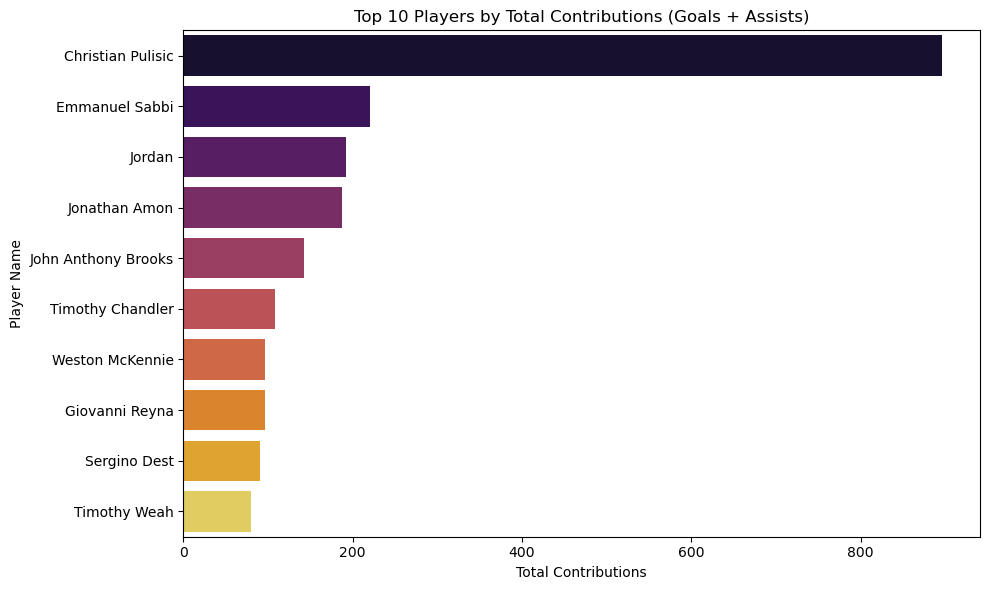

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_players.values, y=top_players.index, palette="inferno") #A vibrant, high-contrast palette that ranges from dark purple to bright yellow, often used for heatmaps and intensity plots.
plt.title("Top 10 Players by Total Contributions (Goals + Assists)")
plt.xlabel("Total Contributions")
plt.ylabel("Player Name")
plt.tight_layout()
plt.show()

* Interpretation : Here are the top 10 players who scored more goals and assists in the matches 

##### Grouping by player_name,position wise Total contributions

In [51]:
top_players1 = (football_df.groupby(['player_name', 'position'])[['total_contributions']].sum().sort_values(by = 'total_contributions',ascending=False).head(10))
top_players1

,,total_contributions
player_name,position,
Christian Pulisic,Attack,896
Emmanuel Sabbi,Attack,220
Jordan,Attack,192
Jonathan Amon,Attack,187
John Anthony Brooks,Defender,143
Timothy Chandler,Defender,108
Weston McKennie,Midfield,96
Giovanni Reyna,Midfield,96
Sergino Dest,Defender,90


##### Player name ,Position wise Total contributions

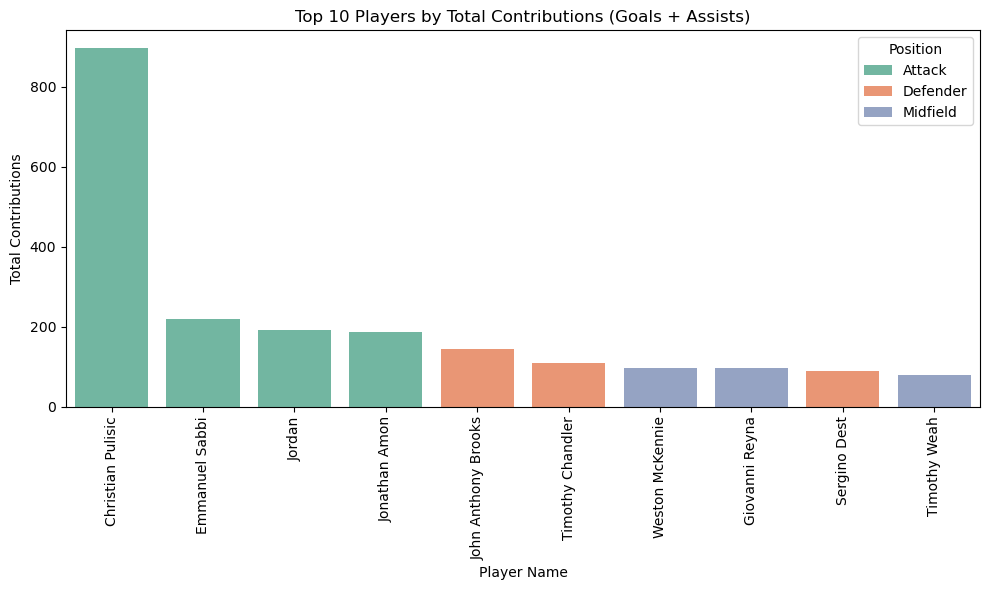

In [53]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_players1,y='total_contributions',x='player_name',hue='position',palette='Set2')
plt.title('Top 10 Players by Total Contributions (Goals + Assists)')
plt.xlabel('Player Name')
plt.ylabel('Total Contributions')
plt.legend(title='Position')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

* Interpretation : Those players who are in the attacking positon score more number goals and assists compared to the players playing in the midfield and defence .In that Christian Pulisic has highest number of goals and assists as a attacker ,then as a defender  John Anthony Brooks hold more goals and assists ,Weston Mckennie has secured more goals and assists has a midfield.

---------------------------------------

##### Probability
* What is the probability that a player received a yellow card and also played as a substitute in the same match?




###### Creting a Categorical column for the yellow cards

In [58]:
bins = [-1,0,1]
labels = ['no','yes']

football_df['yellow_cards_c'] = pd.cut(football_df['yellow_cards'],bins = bins,labels = labels)

In [59]:
## Conditional probability 
## no_of_observation : here the yellow cards received and also been substitute in the match .
no_of_observation = len(football_df[(football_df['yellow_cards_c'] == 'yes') & (football_df['player_role'] == 'substitutes')])
no_of_observation

274

In [60]:
## total_observation : Yellow card is given 
total_observation =  len(football_df['yellow_cards'])
total_observation

3637

In [61]:
p_yc_sub = no_of_observation/total_observation
print('The probability that a player received a yellow card and also played as a substitute in the same match is ',p_yc_sub*100,'%')

The probability that a player received a yellow card and also played as a substitute in the same match is  7.533681605718999 %


##### Interpretation : The probability that a player received a yellow card and also played as a substitute in the same match is  7.53%

--------------------------------------------

##### sampling and clt theorem 
* How does the average number of goals scored in a randomly selected sample of matches compare to the average across the full season? Does the sampling distribution of the sample mean resemble a normal distribution as predicted by the Central Limit Theorem?

##### Creating a column Total goals that contain home club goals and away club goals

In [66]:
football_df['total_goals'] = football_df['home_club_goals'] + football_df['away_club_goals']

##### Creating a 50 sample which represent population'
##### Simple random sampling 

In [68]:
sample =football_df[['home_club_goals', 'away_club_goals', 'total_goals','season']]
sample50 =sample.sample(n = 50,replace = True ,random_state = 30)


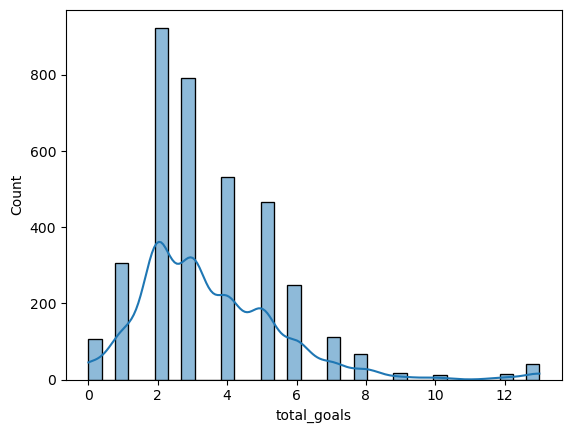

In [69]:
sns.histplot(football_df['total_goals'], kde=True)
plt.show()

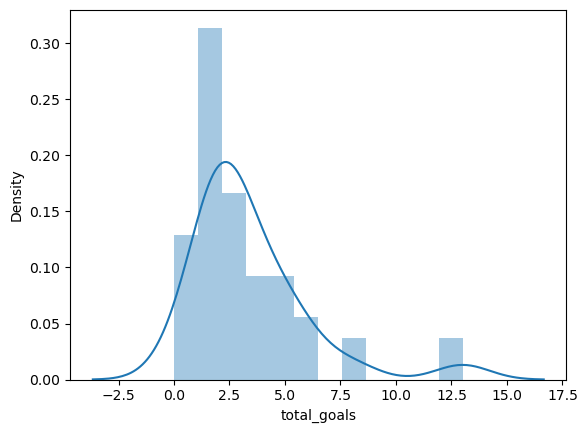

In [70]:
sns.distplot(sample50['total_goals'],kde =True )
plt.show()

* The histogram tends to take the shape of near to normal distribution this is the first rule of the central limit theorm

In [72]:
pop_mean = st.mean(football_df['total_goals'])
pop_median = st.median(football_df['total_goals'])
pop_stdev = st.stdev(football_df['total_goals'])

print(f'Population Mean :{pop_mean}')
print(f'Population Median :{pop_median}')
print(f'Population Standard_devation :{pop_stdev}')

Population Mean :3.516634588946934
Population Median :3
Population Standard_devation :2.150692804651653


In [73]:
mean_50 = st.mean(sample50['total_goals'])
median_50 = st.median(sample50['total_goals'])
stdev_50 = st.stdev(sample50['total_goals'])

print(f'sample Mean :{mean_50}')
print(f'sample Median :{median_50}')
print(f'sample Standard_devation :{stdev_50}')

sample Mean :3.42
sample Median :3.0
sample Standard_devation :2.665654569841015


*  Sample mean is similar to the sample median when the sample size >= 30 ,which implies that sample is becoming normly distributed with the sample size >=30
*  Also in sample  size 50, population is similar to the sample mean so this sample represent properly the population ,so sample size 50 is normally distributed
*  This is proving the second rule of central limit theorem 

##### create 20 samples with 50 each rows

In [76]:
sample_df = pd.DataFrame()
# create 20 samples with 50 each rows  
for i in range(0,20):
    sample_df['sample_'+str(i)]=football_df['total_goals'].sample(n = 40,replace = True).reset_index(drop= True)
# +str covert the numerical value to the string 
sample_df.head()

,sample_0,sample_1,sample_2,sample_3,sample_4,sample_5,sample_6,sample_7,sample_8,sample_9,sample_10,sample_11,sample_12,sample_13,sample_14,sample_15,sample_16,sample_17,sample_18,sample_19
0,5,2,2,1,2,5,3,5,5,2,5,6,5,7,2,2,1,5,2,7
1,1,5,5,2,2,5,5,13,5,6,2,3,1,8,5,3,1,3,2,4
2,4,0,3,5,3,3,7,4,5,2,2,6,2,0,5,2,2,5,2,1
3,2,1,2,2,2,5,3,3,2,7,6,4,1,5,1,3,7,3,3,3
4,2,6,1,7,3,3,3,4,5,2,3,2,3,2,3,7,3,2,1,2


##### Ploting the histogram for those 20 sample .

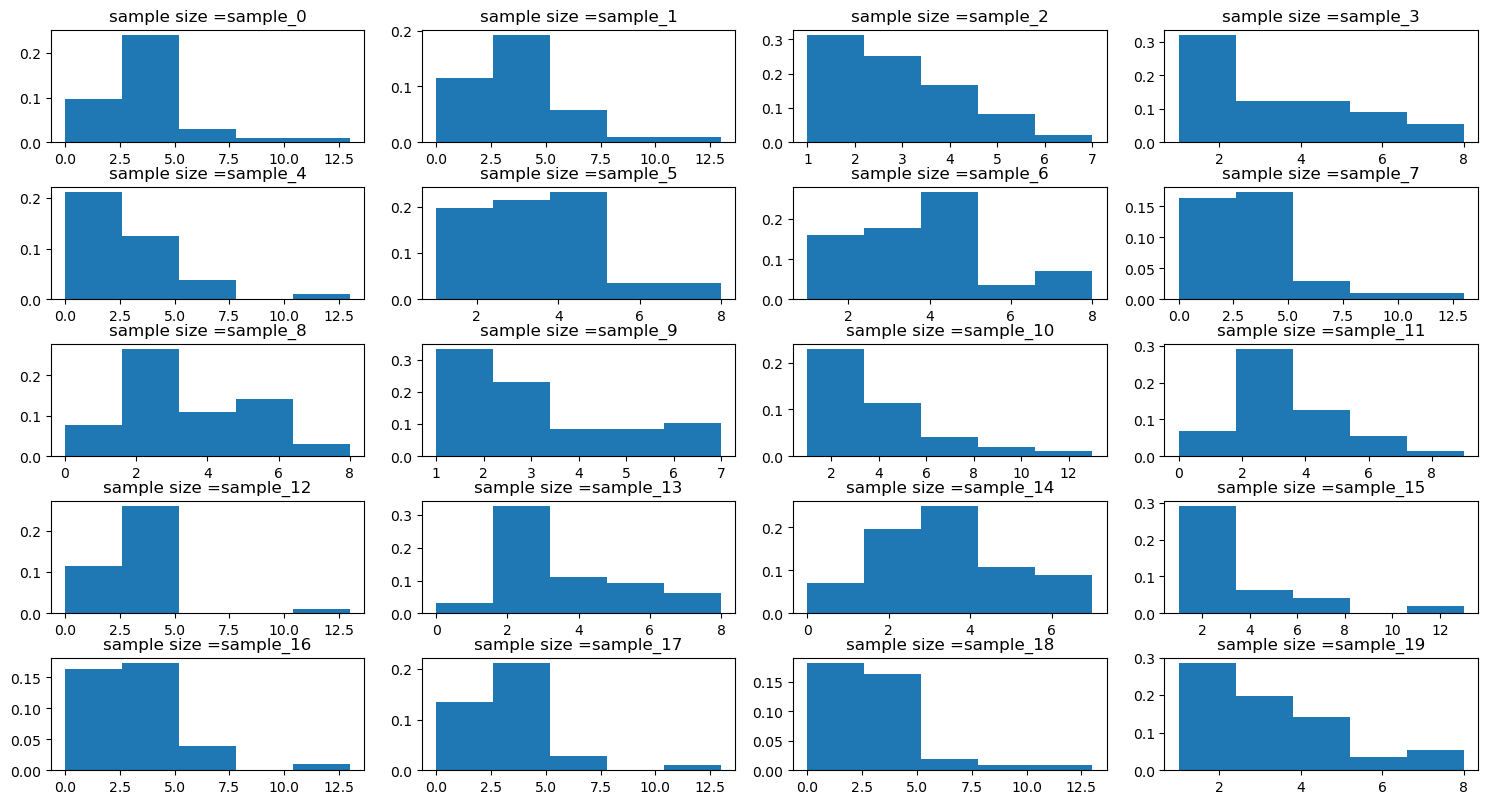

In [78]:
sample_name = sample_df.columns 
fig,ax  = plt.subplots(5,4,figsize = (15,8))
fig.tight_layout()
# histogram position 
k =0
for i in range(0,5):# 5 rows 
    for j in range(0,4):# 4 columns 
        ax[i,j].hist(sample_df[sample_name[k]],5,density = True)
        ax[i,j].set_title(label = 'sample size ='  +sample_name[k])
        k = k+1

plt.show()

##### Calculate mean for all 20 sample 

In [80]:
# calculate mean for all 20 sample 
sample_mean = []
sample_names = sample_df.columns

for i in sample_name:
    #pd.concat([sample_mean,sample_df[i]].mean())
    sample_mean.append(sample_df[i].mean())

samples_mean = pd.DataFrame()
samples_mean.insert(0,'Sample Name',sample_name)
samples_mean.insert(1,'Sample_mean',sample_mean)
samples_mean.head()

,Sample Name,Sample_mean
0,sample_0,3.750
1,sample_1,3.700
2,sample_2,2.975
3,sample_3,3.325
4,sample_4,3.125


##### Calculate the standard deviation of all the 20 sample mean 

In [82]:
# calculate the standard deviation of all the 20 sample mean

sample_mean_std = st.stdev(samples_mean['Sample_mean'])
print("The standard deviation of all 20 sample mean :",sample_mean_std)

The standard deviation of all 20 sample mean : 0.2562989362772349


In [83]:
# calculate the standard deviation from the population parameter 

sample_std = pop_stdev/math.sqrt(50)
print('The sample standard deviation from the population parameter ',sample_std)

The sample standard deviation from the population parameter  0.3041538932836597


* above population data and sample data with the sample size 50 indicating both are normally distributed and sample mean is similar to the population mean this is proving the central limit theorm

##### Bell curve for the population and the sample  

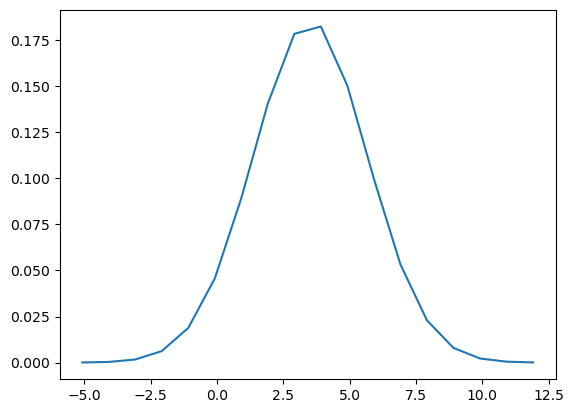

In [86]:
from scipy.stats import norm 


lower_p = pop_mean - 4*pop_stdev
upper_p = pop_mean + 4*pop_stdev

norm_p = np.arange(lower_p,upper_p)
plt.plot(norm_p,norm.pdf(norm_p,pop_mean,pop_stdev))
plt.show()

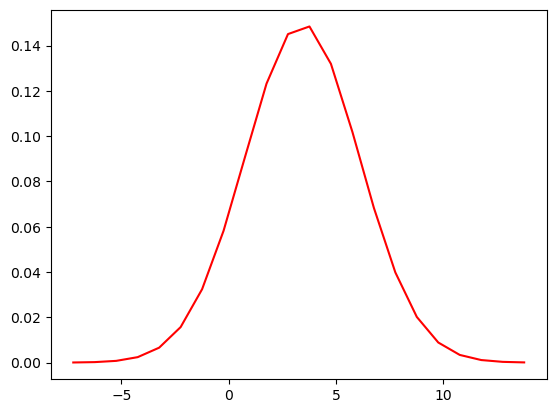

In [87]:
lower_p = mean_50 - 4*stdev_50
upper_p = mean_50 + 4*stdev_50

norm_p = np.arange(lower_p,upper_p)
plt.plot(norm_p,norm.pdf(norm_p,mean_50,stdev_50),color = 'red')
plt.show()

###### ######

---------------------------------------

##### Logistic Regression (Classification)
* "Is a player's country of birth related to their likelihood of receiving a yellow card?"

In [91]:
football_df[['yellow_cards']].value_counts()

yellow_cards
0               3075
1                562
Name: count, dtype: int64

##### converting the categorical columns to numerical  

In [93]:
labelencoder = preprocessing.LabelEncoder()
football_df['foot_n'] = labelencoder.fit_transform(football_df['foot'])
football_df['country_of_birth_n'] = labelencoder.fit_transform(football_df['country_of_birth'])
football_df['player_sub_position_n'] = labelencoder.fit_transform(football_df['player_sub_position'])
football_df['position_n'] = labelencoder.fit_transform(football_df['position'])
football_df['competition_type_n'] = labelencoder.fit_transform(football_df['competition_type'])

##### Creating a variable for the Target columns

In [95]:
yellow = football_df[['yellow_cards']]
yellow

,yellow_cards
0,0
1,0
2,0
3,0
4,0
...,...
3632,0
3633,0
3634,0
3635,0


In [96]:
 football_df[['yellow_cards']].value_counts()

yellow_cards
0               3075
1                562
Name: count, dtype: int64

##### Creating a variable for the feature columns

In [98]:
new_df = football_df[['country_of_birth_n', 'position_n', 'foot_n', 'minutes_played', 'competition_type_n']]
new_df

,country_of_birth_n,position_n,foot_n,minutes_played,competition_type_n
0,1,1,2,70,1
1,1,1,2,70,1
2,1,1,2,70,1
3,1,1,2,70,1
4,1,1,2,70,1
...,...,...,...,...,...
3632,4,0,2,77,1
3633,4,0,2,77,1
3634,4,0,2,77,1
3635,4,0,2,77,1


##### Checking the outliers through boxplot


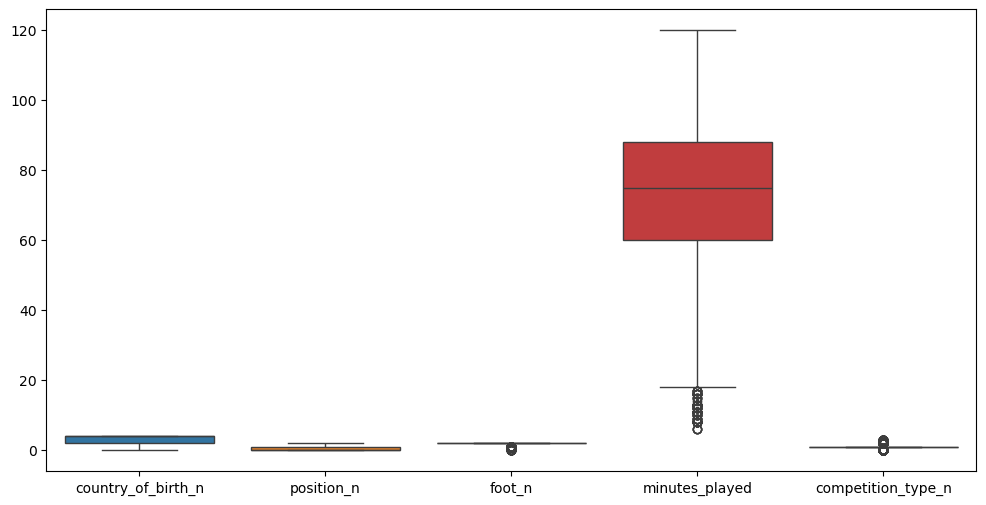

In [100]:
sns.boxplot(data = new_df )
plt.gcf().set_size_inches(12,6)
plt.show()

* In this case the outliers are not to be treated because the values are correct and accurate (ex : if the outliers are treated than the value for assist and goals will changed which might affect the prediction.

##### Performing Data Scaling to avoid the data from being baised 

In [103]:
col = new_df.columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(new_df)
df_scaled = pd.DataFrame(df_scaled,columns = col )
df_scaled

,country_of_birth_n,position_n,foot_n,minutes_played,competition_type_n
0,-1.692769,0.618899,0.431977,-0.000445,-0.014365
1,-1.692769,0.618899,0.431977,-0.000445,-0.014365
2,-1.692769,0.618899,0.431977,-0.000445,-0.014365
3,-1.692769,0.618899,0.431977,-0.000445,-0.014365
4,-1.692769,0.618899,0.431977,-0.000445,-0.014365
...,...,...,...,...,...
3632,0.650817,-0.707522,0.431977,0.333041,-0.014365
3633,0.650817,-0.707522,0.431977,0.333041,-0.014365
3634,0.650817,-0.707522,0.431977,0.333041,-0.014365
3635,0.650817,-0.707522,0.431977,0.333041,-0.014365


##### After Data scaling adding the target variable to the scaled data 

In [105]:
df_scaled = pd.concat([df_scaled,yellow],axis = 1)
df_scaled

,country_of_birth_n,position_n,foot_n,minutes_played,competition_type_n,yellow_cards
0,-1.692769,0.618899,0.431977,-0.000445,-0.014365,0
1,-1.692769,0.618899,0.431977,-0.000445,-0.014365,0
2,-1.692769,0.618899,0.431977,-0.000445,-0.014365,0
3,-1.692769,0.618899,0.431977,-0.000445,-0.014365,0
4,-1.692769,0.618899,0.431977,-0.000445,-0.014365,0
...,...,...,...,...,...,...
3632,0.650817,-0.707522,0.431977,0.333041,-0.014365,0
3633,0.650817,-0.707522,0.431977,0.333041,-0.014365,0
3634,0.650817,-0.707522,0.431977,0.333041,-0.014365,0
3635,0.650817,-0.707522,0.431977,0.333041,-0.014365,0


##### Checking the correlation 

In [107]:
df_scaled.iloc[:, :-1].corr()

,country_of_birth_n,position_n,foot_n,minutes_played,competition_type_n
country_of_birth_n,1.000000,-0.262618,0.278458,-0.060933,0.182608
position_n,-0.262618,1.000000,-0.200577,-0.094034,-0.107716
foot_n,0.278458,-0.200577,1.000000,0.055126,0.017578
minutes_played,-0.060933,-0.094034,0.055126,1.000000,0.032075
competition_type_n,0.182608,-0.107716,0.017578,0.032075,1.000000


In [108]:
# Plotting heatmap

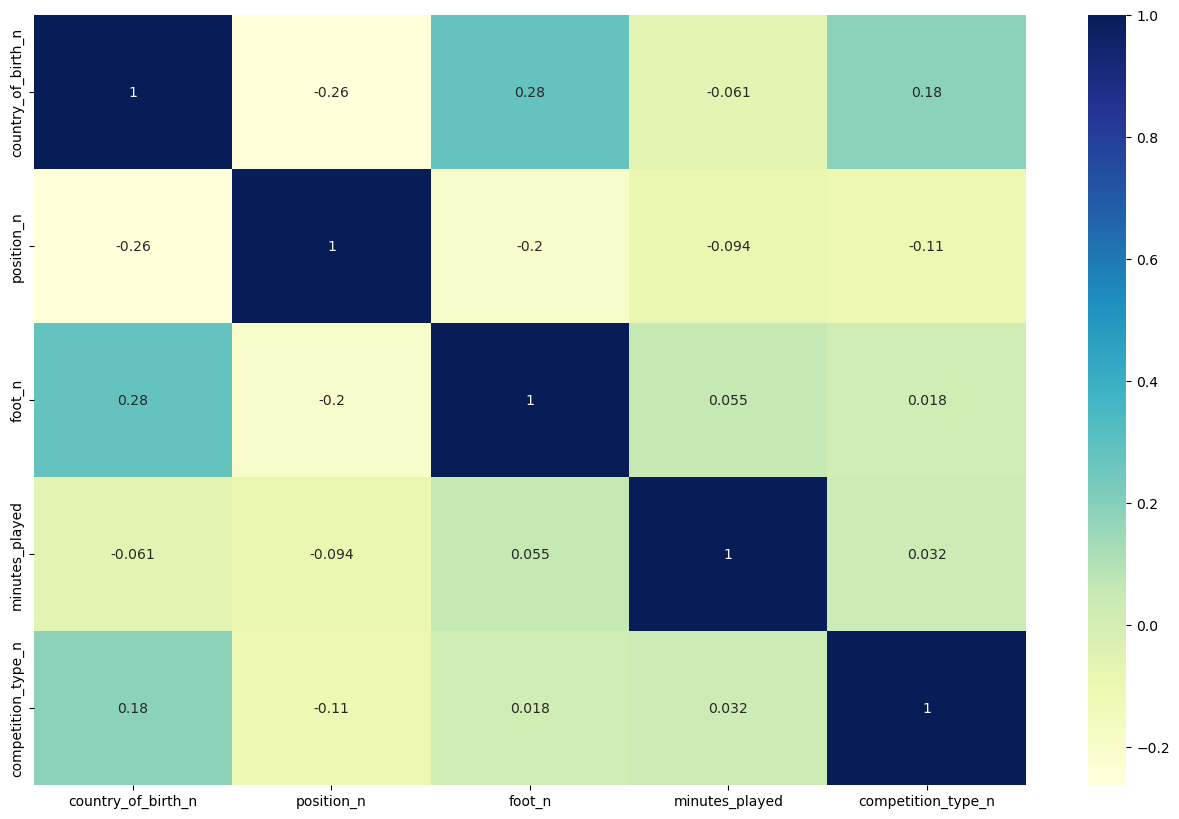

In [109]:

fig, ax = plt.subplots(1,  figsize=(16, 10))
ax = sns.heatmap(df_scaled.iloc[:, :-1].corr(), annot=True, cmap="YlGnBu")
plt.show()

In [110]:
#Creating test and training datasets
train ,test = train_test_split(df_scaled,train_size = 0.8,random_state = 50)
print('Train data set :',train.shape)
print('Test data set :',test.shape)

Train data set : (2909, 6)
Test data set : (728, 6)


In [111]:
x_train = train.drop('yellow_cards',axis = 1)
y_train = train['yellow_cards']
x_test = test.drop(columns = 'yellow_cards' , axis = 1)
y_test = test['yellow_cards']
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((2909, 5), (2909,), (728, 5), (728,))

In [112]:
# Logistic Regression - training the model  
logreg = LogisticRegression(class_weight='balanced')
logreg.fit(x_train, y_train)

# Using the trained model to predict the outcome of the X_Test dataset
Y_pred = logreg.predict(x_test)

In [113]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test , Y_pred))

tn,fp,fn,tp = confusion_matrix(y_test,Y_pred).ravel()# break them convert it to one dimension
print(tn,fp,fn,tp )

[[423 187]
 [ 29  89]]
423 187 29 89


* TN (True Negatives) = 423
→ The model correctly predicted no yellow card (or the negative class), and the player truly had no yellow card.

* FP (False Positives) = 187
→ The model predicted a yellow card, but the player actually did not receive one (a false alarm).

* FN (False Negatives) = 29
→ The model predicted no yellow card, but the player actually did get one (a miss).

* TP (True Positives) = 89
→ The model correctly predicted a yellow card, and the player indeed received one.



In [115]:
print('Recall:',recall_score(y_test , Y_pred))
print('F1 score :',f1_score(y_test , Y_pred))
print('accuracy:',accuracy_score(y_test , Y_pred))
print('precision:',precision_score(y_test , Y_pred))


Recall: 0.7542372881355932
F1 score : 0.4517766497461929
accuracy: 0.7032967032967034
precision: 0.322463768115942


* Recall (0.75)
→ Of all actual positive cases (e.g., players who received yellow cards), the model correctly identified 75.4% of them.
Good recall means few false negatives (FN = 29 in your case).

* Precision (0.32)
→ Of all predicted positives (players flagged as getting a yellow card), only 32.2% actually did.
Low precision means many false positives (FP = 187 in your case).

* F1 Score (0.45)
→ This is the harmonic mean of precision and recall.
It balances the trade-off between false positives and false negatives.
Moderate score suggests imbalance between precision and recall.

* Accuracy (0.70)
→ Overall, 70.3% of all predictions were correct.
But accuracy can be misleading when the classes are imbalanced.

In [117]:
roc = roc_auc_score(y_test, logreg.predict_proba(x_test)[:,1])
roc

0.7759933314809668

* Roc : 77.57% 
→ Fairly strong performance

The model can correctly rank a random positive case (e.g., player who gets a yellow card) higher than a random negative case about 77.6% of the time.



<Figure size 1000x800 with 0 Axes>

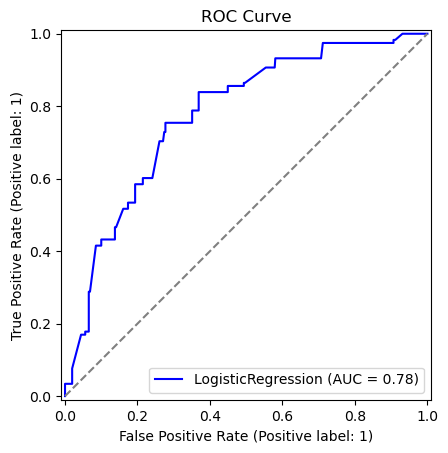

In [119]:
plt.figure(figsize=(10, 8))
RocCurveDisplay.from_estimator(logreg, x_test, y_test, color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title('ROC Curve')
plt.show()

================================================================
------------------------

================================================================
------------------------

-------------

##### #########

### Player Profile and Market Value 
-----------------------------
##### Descriptive Analysis & Visualization
* How do players' market values vary by position and nationality, and which positions tend to have the highest average market value?

##### Prediction using Linear Regression
* how do a football player's position, performance, and background influence their height?
 

###### #

--------------------------------

##### Descriptive Analysis & Visualization
* How do players' market values vary by position and nationality, and which positions tend to have the highest average market value?

##### Grouped by position wise average market value 

In [129]:
market_value = football_df.groupby('position')['market_value_in_eur'].mean()
market_value

position
Attack      1.320079e+07
Defender    2.339010e+06
Midfield    1.766299e+07
Name: market_value_in_eur, dtype: float64

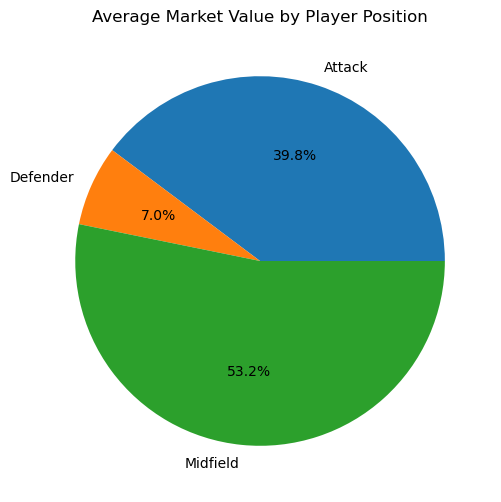

In [130]:
plt.figure(figsize = (11,6))
plt.pie(market_value.values, labels=market_value.index, autopct='%1.1f%%')
plt.title("Average Market Value by Player Position")
plt.show()

* Interpretation : Many teams invest more money on the mid-feild because they can perform both the defence and attack as per the match requirement ,also the market value for the defender is too low compared to attacker and midfield.

##### Groupby country and position wise market value for the better understanding  

In [133]:
market_value = football_df.groupby(['country_of_birth','position'])[['market_value_in_eur']].mean().sort_values(by = 'market_value_in_eur',ascending = False)
market_value

market_value_in_eur
country_of_birth position                     
England          Midfield         2.500000e+07
United States    Midfield         1.642294e+07
                 Attack           1.590674e+07
Netherlands      Defender         1.000000e+07
United States    Defender         1.844811e+06
Germany          Defender         1.464322e+06
Italy            Attack           8.000000e+05
Germany          Attack           7.500000e+05

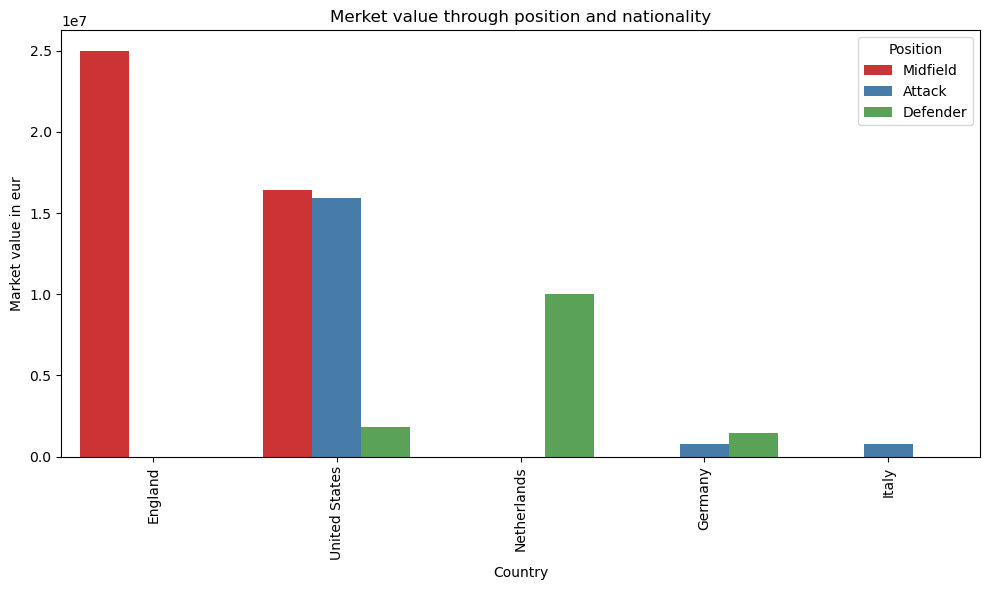

In [134]:
plt.figure(figsize=(10, 6))
sns.barplot(data=market_value,y='market_value_in_eur',x='country_of_birth',hue='position',palette='Set1')
plt.title('Merket value through position and nationality')
plt.xlabel('Country')
plt.ylabel('Market value in eur')
plt.legend(title='Position')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

* Interpretation : Each country contribute more currency in different position , in that united states focuses in all three position (attack,defender,midfield) .Other countries like England ,Italy ,Netherland are focusing only in specific position then Germany concentrate in two areas (attack,defender)

---------------------------------

##### #

#### Prediction using Linear Regression

* How do a football player's position, performance, and background influence their height?
 
* Target: height_in_cm

* Features:  highest_market_value_in_eur','height_in_cm','goals','assists','foot_n','minutes_played','player_sub_position_n','position_n'.

In [139]:
feature = football_df[['market_value_in_eur','height_in_cm','goals','assists','minutes_played','position_n']]
feature

,market_value_in_eur,height_in_cm,goals,assists,minutes_played,position_n
0,700000.0,186.0,0,0,70,1
1,700000.0,186.0,0,0,70,1
2,700000.0,186.0,0,0,70,1
3,700000.0,186.0,0,0,70,1
4,700000.0,186.0,0,0,70,1
...,...,...,...,...,...,...
3632,300000.0,176.0,1,0,77,0
3633,300000.0,176.0,1,0,77,0
3634,300000.0,176.0,1,0,77,0
3635,300000.0,176.0,1,0,77,0


##### performing the data scaling to avoid data baised 

In [141]:
col1 = feature.columns
scaled = StandardScaler()
df_scaled1 = scaled.fit_transform(feature)
df_scaled1 = pd.DataFrame(df_scaled1,columns = col1)
df_scaled1

,market_value_in_eur,height_in_cm,goals,assists,minutes_played,position_n
0,-1.004730,0.679979,-0.787909,-0.384674,-0.000445,0.618899
1,-1.004730,0.679979,-0.787909,-0.384674,-0.000445,0.618899
2,-1.004730,0.679979,-0.787909,-0.384674,-0.000445,0.618899
3,-1.004730,0.679979,-0.787909,-0.384674,-0.000445,0.618899
4,-1.004730,0.679979,-0.787909,-0.384674,-0.000445,0.618899
...,...,...,...,...,...,...
3632,-1.041634,-0.882692,0.844925,-0.384674,0.333041,-0.707522
3633,-1.041634,-0.882692,0.844925,-0.384674,0.333041,-0.707522
3634,-1.041634,-0.882692,0.844925,-0.384674,0.333041,-0.707522
3635,-1.041634,-0.882692,0.844925,-0.384674,0.333041,-0.707522


In [142]:
### heatmap to see the correlation

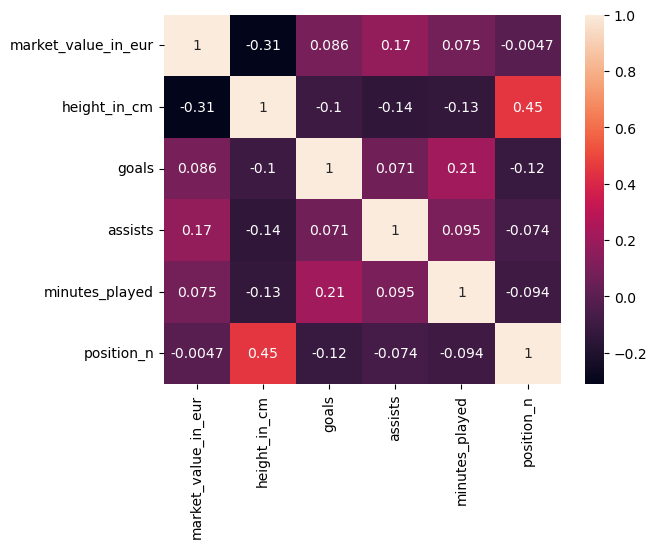

In [143]:
sns.heatmap(data = feature.corr(),annot = True)

plt.show()

In [144]:
df_scaled1.corr()[['market_value_in_eur']].sort_values(by = 'market_value_in_eur',ascending = False)

,market_value_in_eur
market_value_in_eur,1.000000
assists,0.173060
goals,0.086465
minutes_played,0.075445
position_n,-0.004735
height_in_cm,-0.311879


In [145]:
#### spliting the train and test data for the model 

In [146]:
x = np.array(df_scaled1['assists']).reshape(-1,1)
y = np.array(df_scaled1['market_value_in_eur'])
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 14)

In [147]:
# Build model and fit with data
s_model = LinearRegression().fit(x_train,y_train)
s_model.score(x_train,y_train)

0.027914343103330186

In [148]:
# print intercept and slope of the model
print("Intercept:",s_model.intercept_)
print("Slope:",s_model.coef_)

Intercept: 0.004696107614689253
Slope: [0.16081523]


In [149]:
# Predict the model using test data
y_predict = s_model.predict(x_test)
y_predict

array([-0.05716533, -0.05716533,  0.37467738, ..., -0.05716533,
       -0.05716533, -0.05716533])

In [150]:
#### calculate the mse,mae,rmse to evaluate the model performance 

In [151]:
mse = mean_squared_error(y_test,y_predict) 
mae = mean_absolute_error(y_test,y_predict) 
rmse =mean_squared_error(y_test,y_predict,squared = False)
print('root_mean_squared_error',rmse)
print('mean_squared_error',mse)
print('mean_absolute_error',mae)

root_mean_squared_error 0.9930395714251089
mean_squared_error 0.9861275904161639
mean_absolute_error 0.9492253255368032


##### calculate the r2 score 

In [153]:
R2= r2_score(y_test,y_predict)
R2

0.033419226465584595

In [154]:
test_df.columns

Index(['Unnamed: 0', 'appearance_id', 'game_id', 'player_id', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played',
       'season', 'round', 'home_club_goals', 'away_club_goals',
       'home_club_position', 'away_club_position', 'home_club_manager_name',
       'away_club_manager_name', 'stadium', 'attendance', 'referee',
       'home_club_name', 'away_club_name', 'aggregate', 'competition_type',
       'game_event_id', 'date', 'minute', 'type_x', 'player_in_id', 'name',
       'last_season', 'current_club_id', 'player_code', 'country_of_birth',
       'date_of_birth', 'sub_position', 'position_x', 'foot', 'height_in_cm',
       'market_value_in_eur', 'highest_market_value_in_eur',
       'contract_expiration_date', 'game_lineups_id', 'type_y', 'number',
       'player_name', 'team_captain', 'position_y'],
      dtype='object')

In [155]:
label = preprocessing.LabelEncoder()
test_df['foot_n'] = label.fit_transform(test_df['foot'])

In [156]:
test_df['position_n'] = label.fit_transform(test_df['position_x'])
test_df['player_sub_position_n'] = label.fit_transform(test_df['position_y'])

In [157]:
test_fe =  test_df[['market_value_in_eur','height_in_cm','goals','assists','minutes_played','position_n']]
test_fe

,market_value_in_eur,height_in_cm,goals,assists,minutes_played,position_n
0,3000000,177,0,0,58,0
1,3000000,177,0,0,58,0


In [158]:
test_df_num = test_df.select_dtypes(include = 'number')
test_df_num

,Unnamed: 0,game_id,player_id,yellow_cards,red_cards,goals,assists,minutes_played,season,home_club_goals,...,last_season,current_club_id,height_in_cm,market_value_in_eur,highest_market_value_in_eur,number,team_captain,foot_n,position_n,player_sub_position_n
0,4197,3450613,315762,0,0,0,0,58,2020,4,...,2023,940,177,3000000,3000000,14,0,0,0,1
1,4198,3450613,315762,0,0,0,0,58,2020,4,...,2023,940,177,3000000,3000000,14,0,0,0,0


In [159]:
col = test_fe.columns
df_scaled_test = scaled.transform(test_fe)
df_scaled_test = pd.DataFrame(df_scaled_test,columns = col)
df_scaled_test

,market_value_in_eur,height_in_cm,goals,assists,minutes_played,position_n
0,-0.792531,-0.726425,-0.787909,-0.384674,-0.572135,-0.707522
1,-0.792531,-0.726425,-0.787909,-0.384674,-0.572135,-0.707522


In [160]:
y_predict_test = s_model.predict(df_scaled_test[['assists']])
y_predict_test

array([-0.05716533, -0.05716533])

In [161]:
#plot in linear regression 
def calculating_residuals(model,features,label):
    Predictions=model.predict(features)
    df_results=pd.DataFrame({"Actual":label,"Predictions":Predictions})
    df_results["Residuals"]=abs(df_results["Actual"])-abs(df_results["Predictions"])
    return df_results
def Linear_regression(model,feature,label):
    df_results=calculating_residuals(model,feature,label)
    sns.lmplot(x="Actual",y="Predictions",data=df_results,fit_reg=False)
    line_cords=np.arange(df_results.min().min(),df_results.max().max())
    plt.plot(line_cords,color="red",linestyle="--")
    plt.title("Linear Regression plot")
    plt.show()

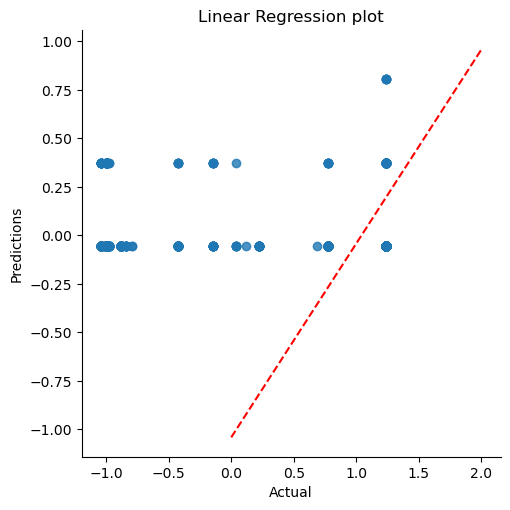

In [162]:
Linear_regression(s_model,x_test,y_test)

##### Interpretation of the Plot:
* The predicted values (blue dots) are heavily clustered around 0.

* Very few points align closely with the red dashed line.

* Most predictions are underestimating the actual values, especially for players with higher market value.                                                                                                                     
                                                                                                                               

### Multiple Regression 

##### considering the two features and target for the multiple regression 

In [166]:
x2 = np.array(df_scaled1[['assists','goals']])
y2 = np.array(df_scaled1['market_value_in_eur'])
x2_train,x2_test,y_train,y_test = train_test_split(x2,y2,test_size = 0.3,random_state = 1)

In [167]:
# Build model and fit with data
s_model1 = LinearRegression().fit(x2_train,y_train)
s_model1.score(x2_train,y_train)

0.03701719219605171

In [168]:
# print intercept and slope of the model
print("Intercept:",s_model1.intercept_)
print("Slope:",s_model1.coef_)

Intercept: -0.01153300054032921
Slope: [0.17031635 0.08069904]


In [169]:
# Predict the model using test data
y_predict2 = s_model1.predict(x2_test)
y_predict2

array([-0.00886462, -0.00886462, -0.00886462, ..., -0.14063273,
        0.44849176, -0.14063273])

In [170]:
mse = mean_squared_error(y_test,y_predict2) 
mae = mean_absolute_error(y_test,y_predict2) 
rmse =mean_squared_error(y_test,y_predict2,squared = False)
print('root_mean_squared_error',rmse)
print('mean_squared_error',mse)
print('mean_absolute_error',mae)

root_mean_squared_error 0.9865859819174478
mean_squared_error 0.9733518997160147
mean_absolute_error 0.9349718656769074


In [171]:
R2_2= r2_score(y_test,y_predict2)
R2_2

0.030620578164887835

In [172]:
x3 = np.array(df_scaled1[['assists','goals','minutes_played']])
y3 = np.array(df_scaled1['market_value_in_eur'])
x3_train,x3_test,y_train,y_test = train_test_split(x3,y3,test_size = 0.3,random_state = 1)

In [173]:
# Build model and fit with data
s_model2 = LinearRegression().fit(x3_train,y_train)
s_model2.score(x3_train,y_train)

0.03965284819881265

In [174]:
# print intercept and slope of the model
print("Intercept:",s_model2.intercept_)
print("Slope:",s_model2.coef_)

Intercept: -0.01149110837014006
Slope: [0.16666429 0.07101408 0.05198478]


In [175]:
# Predict the model using test data
y_predict3 = s_model2.predict(x3_test)
y_predict3

array([ 0.00666529,  0.00914189,  0.03390788, ..., -0.12662508,
        0.46659769, -0.14396127])

In [176]:
mse = mean_squared_error(y_test,y_predict3) 
mae = mean_absolute_error(y_test,y_predict3) 
rmse =mean_squared_error(y_test,y_predict3,squared = False)
print('root_mean_squared_error',rmse)
print('mean_squared_error',mse)
print('mean_absolute_error',mae)

root_mean_squared_error 0.9863746476623817
mean_squared_error 0.9729349455510876
mean_absolute_error 0.9332782647172292


In [177]:
from sklearn.metrics import r2_score
R2_3= r2_score(y_test,y_predict3)
R2_3

0.031035830641866324

In [178]:
x4 = np.array(df_scaled1[['assists','goals','minutes_played','height_in_cm']])
y4 = np.array(df_scaled1['market_value_in_eur']) 
x4_train,x4_test,y_train,y_test = train_test_split(x4,y4,test_size = 0.3,random_state = 7)

In [179]:
# Build model and fit with data
s_model3 = LinearRegression().fit(x4_train,y_train)
s_model3.score(x4_train,y_train)

0.10704374859666022

In [180]:
# print intercept and slope of the model
print("Intercept:",s_model3.intercept_)
print("Slope:",s_model3.coef_)

Intercept: -0.002036384535672807
Slope: [ 0.11581713  0.06330124  0.02455364 -0.27631697]


In [181]:
# Predict the model using test data
y_predict4 = s_model3.predict(x4_test)
y_predict4

array([0.10541857, 0.21462776, 0.41291704, ..., 0.09840003, 0.21930678,
       0.12179515])

In [182]:
mse = mean_squared_error(y_test,y_predict4) 
mae = mean_absolute_error(y_test,y_predict4) 
rmse =mean_squared_error(y_test,y_predict4,squared = False)
print('root_mean_squared_error',rmse)
print('mean_squared_error',mse) 
print('mean_absolute_error',mae)

root_mean_squared_error 0.928594121851684
mean_squared_error 0.8622870431375002
mean_absolute_error 0.8432713964414754


In [183]:
from sklearn.metrics import r2_score
R2_4= r2_score(y_test,y_predict4)
R2_4 

0.1368291254946168

Interpretation : 
* Error Metrics

The Root Mean Squared Error (RMSE) is 0.73, and Mean Absolute Error (MAE) is 0.53, indicating the model's average prediction error for height is less than 1 cm — a reasonably good accuracy.

* Model Fit (R² Score)

With an R² score of ~0.49, about 49% of the variation in player height is explained by the input features (position_n, highest_market_value_in_eur, foot_n, player_sub_position_n).

* Feature Impact

Positional roles and market value show a moderate influence on predicting height, suggesting a relationship between a player's role/type and their physical attributes.

* Limitations & Next Steps

The model leaves ~51% of the variance unexplained.


In [185]:
# Checking Homoscedasticity: Plot the residuals of linear regression
def homoscedasticity_assumption(model, features, label):
    """
    Homoscedasticity: Assumes that the errors exhibit constant variance
    """
    print('Assumption: Homoscedasticity of Error Terms', '\n')
    print('Residuals should have relative constant variance')
    
    #calculating residuals for the plot
    df_results=calculating_residuals(model, features,label)
    print(df_results)
    
    #plotting the residuals
    fig,ax=plt.subplots()
    #plt.subplots(figsize=(12,10))
    ax=plt.subplot(111) #to remove spines
    plt.scatter(x=df_results.index,y=df_results.Residuals,alpha=0.5)
    plt.plot(np.repeat(0,df_results.index.max()),color="green",linestyle="--")
    plt.title("Residual Plot")
    plt.xlabel("Index")
    plt.ylabel("Residual")
    plt.show()

Assumption: Homoscedasticity of Error Terms 

Residuals should have relative constant variance
        Actual  Predictions  Residuals
0     1.237200     0.105419   1.131781
1     1.237200     0.214628   1.022572
2     1.237200     0.412917   0.824283
3    -0.884791    -0.503043   0.381748
4    -1.041634     0.191777   0.849857
...        ...          ...        ...
1087  1.237200     0.101909   1.135290
1088  1.237200     0.110098   1.127102
1089  1.237200     0.098400   1.138800
1090  1.237200     0.219307   1.017893
1091  1.237200     0.121795   1.115404

[1092 rows x 3 columns]


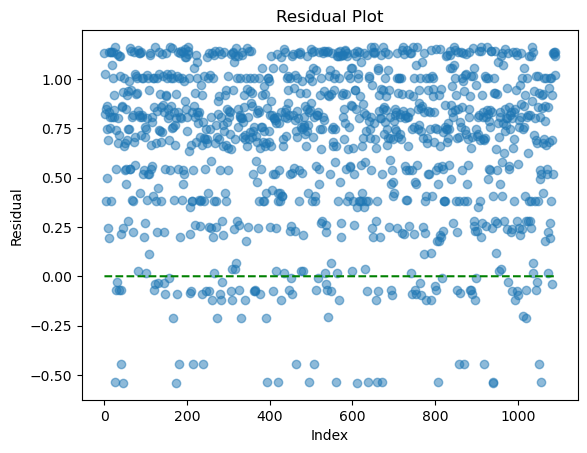

In [186]:
# calling the function
homoscedasticity_assumption(s_model3, x4_test,y_test)

* The residual plot shows that the linear regression model is underestimating market value, with most errors being large and positive. The residuals are not randomly scattered, indicating model bias and possible underfitting. It also shows non-constant error variance, meaning linear regression may not be suitable for this data.

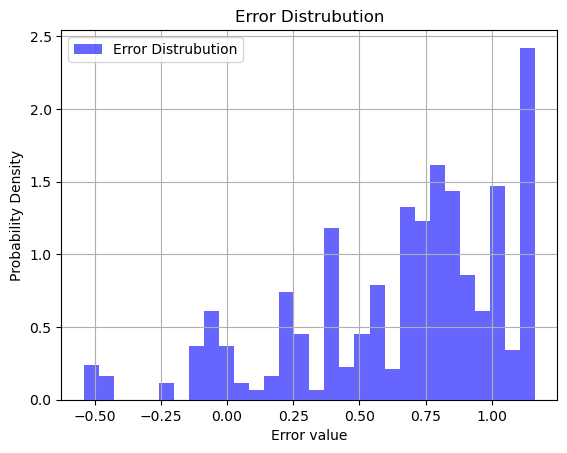

In [188]:
# Code to Error Normality curve
df_results = calculating_residuals(s_model3, x4_test,y_test)
plt.hist(df_results.Residuals,bins=30,label="Error Distrubution",alpha=0.6,density=True,color="blue")
plt.xlabel("Error value")
plt.ylabel("Probability Density")
plt.title("Error Distrubution")
plt.legend()
plt.grid(True)
plt.show()

* The error distribution plot is skewed to the left and not centered around zero, meaning:

* Errors are mostly positive, so predictions are lower than actual values (underestimation).

* The distribution is not normal, violating a key linear regression assumption.

* Indicates model bias and that linear regression is likely not fitting the data well.

================================================================
------------------------

================================================================
------------------------

-------------------------------

### Team Comparison
---------
##### Descriptive Analysis & Visualization
* How does the average number of goals scored by home vs. away teams compare across different seasons?

##### Hypothesis Testing
* Is there a statistically significant difference in the average number of goals scored by teams when playing at home versus when playing away during a season?

-----------------------

##### #

#### Descriptive Analysis & Visualization
##### Done in tableau

--------------------

##### Hypothesis Testing

Is there a statistically significant difference in the average number of goals scored by teams when playing at home versus when playing away during a season?

In [200]:
pro = football_df[football_df['season'] == 2020 ][['season','home_club_goals','away_club_goals']].reset_index()
pro

,index,season,home_club_goals,away_club_goals
0,3501,2020,1,2
1,3502,2020,1,2
2,3503,2020,1,2
3,3504,2020,1,2
4,3505,2020,1,2
...,...,...,...,...
131,3632,2020,3,2
132,3633,2020,3,2
133,3634,2020,3,2
134,3635,2020,3,2


In [201]:
H0 = 'There is same in the average number of goals scored by teams when playing at home versus when playing away during a season'
H1 = 'There is difference in the average number of goals scored by teams when playing at home versus when playing away during a season'

In [202]:
# The test to be performed here is t-test ,because the popultion mean is unknown and sample size is lesser than 30 .
# It is two-tailed test because there is difference in the average number of goals scored by teams when playing at home versus when playing away during a season'

In [203]:
sam1 = pro.sample(n=25,random_state = 10)
sam1

,index,season,home_club_goals,away_club_goals
75,3576,2020,3,0
132,3633,2020,3,2
41,3542,2020,0,5
101,3602,2020,1,1
128,3629,2020,3,2
70,3571,2020,3,0
91,3592,2020,1,1
59,3560,2020,0,5
79,3580,2020,3,0
97,3598,2020,1,1


In [204]:
x_h = st.mean(sam1['home_club_goals'])
x_a =  st.mean(sam1['away_club_goals'])
v1 = st.stdev(sam1['home_club_goals'])**2
v2 = st.stdev(sam1['away_club_goals'])**2
n1 = 25
n2 = 25
dof1 = n1 -1
dof2 = n2 - 2
dof = n1+n2 - 2
alpha = 0.05

print('Home club sample Mean:',x_h)
print('Away club sample Mean:',x_a)
print('Home club sample size:',n1)
print('Away club sample size:',n2)

print('Home club Variance:',v1)
print('Away club Variance:',v2)
 

Home club sample Mean: 1.56
Away club sample Mean: 2.24
Home club sample size: 25
Away club sample size: 25
Home club Variance: 2.0900000000000003
Away club Variance: 3.7733333333333334


In [205]:
signal = abs(x_h-x_a) 
noise  = math.sqrt(v1*(dof1)+v2*(dof2))*math.sqrt(1/n1 + 1/n2)
t_statisiics = signal/noise
print('t_statisiics"',t_statisiics)
p_value = t.sf(abs(t_statisiics),dof)*2
print('p_value:',p_value)
t_critical = t.ppf(1-alpha/2,dof)
print('t_critical:',t_critical)

t_statisiics" 0.2054415042388176
p_value: 0.838095996102199
t_critical: 2.010634757624232


In [206]:
if p_value > alpha:
    print('Accept null hypothesis:',H0)
else:
    print('Accept Alternative hypoythesis:',H1)

Accept null hypothesis: There is same in the average number of goals scored by teams when playing at home versus when playing away during a season


================================================================
------------------------

================================================================
------------------------

----------------------------------

###### #

### Attendance and Stadium Analysis
--------------------
##### Descriptive Analysis & Visualization
* Which stadiums have the highest average attendances, and how does attendance vary by competition type?
* How does attendance trend over time across stadiums or seasons?

#####  K-Nearest Neighbors (KNN) Classification
* Can we classify matches as high or low attendance based on features like competition type, goals scored, and stadium?

-----------------------

##### #

#### Descriptive Analysis & Visualization
* Which stadiums have the highest average attendances, and how does attendance vary by competition type?
* How does attendance trend over time across stadiums or seasons?


##### Grouped the top 5 stadium based on the attendace average 

In [216]:
att = football_df.groupby(['stadium'])[['attendance']].mean().sort_values(by = 'attendance',ascending = False).head(5)
att

,attendance
stadium,
Santiago Bernabeu,76894.000000
Allianz Arena,74666.666667
SIGNAL IDUNA PARK,73482.665402
Civitas Metropolitano,61023.000000
Mercedes-Benz Arena,58605.058824


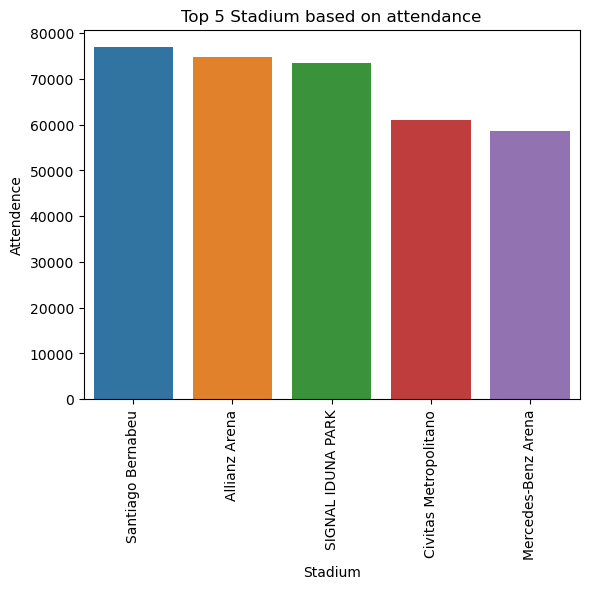

In [217]:
sns.barplot(data = att,x= 'stadium',y = 'attendance',palette='tab10')
plt.xticks(rotation = 90)
plt.title('Top 5 Stadium based on attendance')
plt.xlabel('Stadium')
plt.ylabel('Attendence')
plt.show()


* Interpretation : These are Top 5 stadium with the average attendance ,in that Santiago Bernabeu is the top were many audience occur during the matches 

##### Gruopby stadium and competition wise attendance average

In [220]:
com = football_df.groupby(['stadium','competition_type'])[['attendance']].mean().sort_values(by = 'attendance',ascending = False).head(5)
com

attendance
stadium               competition_type             
SIGNAL IDUNA PARK     other                 81360.0
                      domestic_cup          77048.5
Santiago Bernabeu     international_cup     76894.0
Allianz Arena         domestic_league       75000.0
Olympiastadion Berlin domestic_cup          74322.0

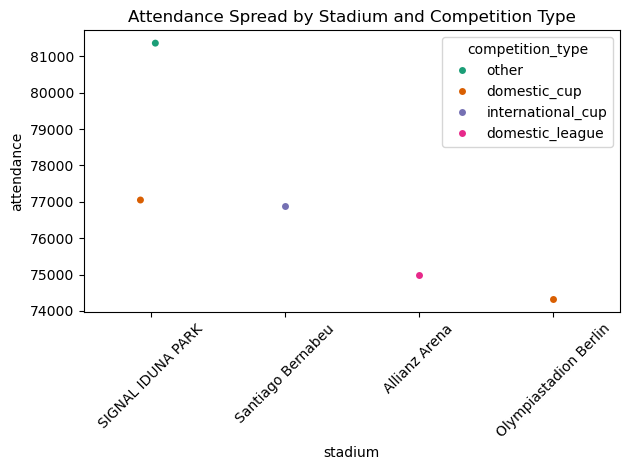

In [221]:
sns.stripplot(data=com, x='stadium', y='attendance', hue='competition_type', palette='Dark2')
plt.xticks(rotation=45)
plt.title('Attendance Spread by Stadium and Competition Type')
plt.tight_layout()
plt.show()

* Interpretation : Here for the deeper analysis consider the competition type which shows the that at what match the more number of crowd occured ,in that domestic and international cup match has more attendance which more fans we attended in these two matches.

---------------------------

##### K-Nearest Neighbors (KNN) Classification

##### Can we classify whether a match will have above-average attendance based on the competition type, home team, and number of goals scored?


* attendance (target: high/medium/low)

* competition_type,home_club_name,home_club_goals,away_club_goals

----------------------------

In [227]:
football_df['attendance'].max()

81365.0

In [228]:
football_df.attendance.value_counts().sort_values(ascending = True)

attendance
33003.913580      1
21177.765432      1
21329.382716      1
21481.000000      1
18751.888889      1
               ... 
50000.000000     44
300.000000       46
81365.000000     57
42100.000000     60
81360.000000    154
Name: count, Length: 599, dtype: int64

In [229]:
def absenteeism(hours):
    if hours <= 30000:
        return 'low'
    elif 30000 < hours <= 60000:
        return 'medium'
    else:
        return 'high'

football_df['attendance_cat'] = football_df['attendance'].apply(absenteeism)

In [230]:
attendance_cat = football_df['attendance_cat'].value_counts()
attendance_cat.index

Index(['low', 'medium', 'high'], dtype='object', name='attendance_cat')

##### Using labelencoder converting the categorical column to the numerical column .

In [232]:
label_encoder = preprocessing.LabelEncoder()
football_df['attendance_num'] = label_encoder.fit_transform(football_df['attendance_cat'])
football_df['competition_type_n'] = label_encoder.fit_transform(football_df['competition_type'])
football_df['home_club_name_n'] = label_encoder.fit_transform(football_df['home_club_name'])

In [233]:
football_df.columns 

Index(['appearance_id', 'player_id', 'yellow_cards', 'red_cards', 'goals',
       'assists', 'minutes_played', 'season', 'round', 'home_club_goals',
       'away_club_goals', 'home_club_position', 'away_club_position',
       'home_club_manager_name', 'away_club_manager_name', 'stadium',
       'attendance', 'referee', 'home_club_name', 'away_club_name',
       'aggregate', 'competition_type', 'game_event_id', 'date', 'minute',
       'event_type', 'player_in_id', 'player_assist_id', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'date_of_birth',
       'sub_position', 'position', 'foot', 'height_in_cm',
       'market_value_in_eur', 'highest_market_value_in_eur',
       'contract_expiration_date', 'game_lineups_id', 'player_role', 'number',
       'team_captain', 'player_sub_position', 'player_name', 'game_id',
       'total_contributions', 'yellow_cards_c', 'total_goals', 'foot_n',
       'country_of_birth_n', 'player_sub_position_n', 'position_n'

In [234]:
knn = football_df[['competition_type_n','total_goals','minutes_played']]
knn

,competition_type_n,total_goals,minutes_played
0,1,3,70
1,1,3,70
2,1,3,70
3,1,3,70
4,1,3,70
...,...,...,...
3632,1,5,77
3633,1,5,77
3634,1,5,77
3635,1,5,77


In [235]:
tar = football_df['attendance_num']
tar

0       2
1       2
2       2
3       2
4       2
       ..
3632    1
3633    1
3634    1
3635    1
3636    1
Name: attendance_num, Length: 3637, dtype: int32

##### perform data scaling to avoid the data from being baised 

In [237]:
scaled = StandardScaler()
column = knn.columns
df_scaled_knn  = scaled.fit_transform(knn)
df_scaled_knn = pd.DataFrame(df_scaled_knn,columns = column)
df_scaled_knn.head()


,competition_type_n,total_goals,minutes_played
0,-0.014365,-0.240251,-0.000445
1,-0.014365,-0.240251,-0.000445
2,-0.014365,-0.240251,-0.000445
3,-0.014365,-0.240251,-0.000445
4,-0.014365,-0.240251,-0.000445


##### Adding the target column to the scaled data .

In [239]:
new_scaled = pd.concat([df_scaled_knn,tar],axis = 1)

In [240]:
# spliting the train and test data .
x_1 = df_scaled_knn
y_1 = tar

x_train_knn,x_test_knn,y_train_knn,y_test_knn = train_test_split(x_1,y_1,test_size = 0.3,random_state = 10)
x_train_knn.shape,y_test_knn.shape

((2545, 3), (1092,))

##### Calculating the k value using the error 

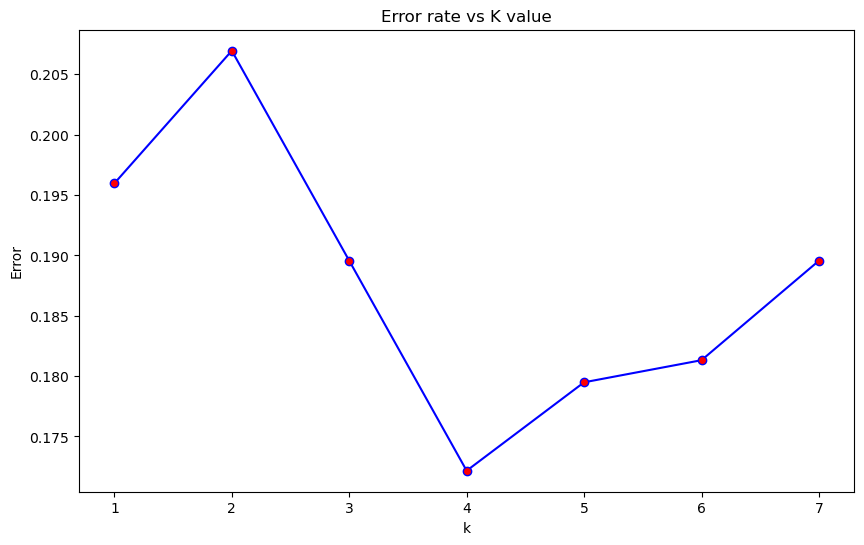

In [242]:
# set range between 1 to 8
error_rate = []
for i in range(1, 8):
    clf = neighbors.KNeighborsClassifier(n_neighbors = i)
    clf.fit(x_train_knn, y_train_knn)
    pred = clf.predict(x_test_knn)
    error_rate.append(np.mean(pred != y_test_knn))

plt.figure(figsize = (10,6))
plt.plot(range(1,8), error_rate, color = 'blue', marker = 'o', markerfacecolor = 'red')
plt.title("Error rate vs K value")
plt.xlabel("k")
plt.ylabel("Error")
plt.show()


* The KNN model performs best at k = 4, achieving the lowest error rate (~17.3%), indicating a reasonable classification capability.


In [244]:
### Building Model
from sklearn import neighbors

k = 4
clf = neighbors.KNeighborsClassifier(n_neighbors=k)
clf.fit(x_1, y_1)

print("Classes:", clf.classes_)
print("Number of neighbors:", clf.n_neighbors)

Classes: [0 1 2]
Number of neighbors: 4


In [245]:
# Using the trained model to predict the outcome of the X_Test dataset
y_pred_knn = clf.predict(x_test_knn)
print(y_pred_knn)

[2 0 2 ... 1 2 2]


In [246]:
print('accuracy_score:',accuracy_score(y_test_knn,y_pred_knn))
print('f1_score:', f1_score(y_test_knn,y_pred_knn, average = 'macro'))
print('recall_score:', recall_score(y_test_knn,y_pred_knn, average = 'macro'))
print('precision_score:', precision_score(y_test_knn,y_pred_knn, average ='macro'))

accuracy_score: 0.782051282051282
f1_score: 0.7832277146368449
recall_score: 0.7741599566247904
precision_score: 0.7947163644239668


In [247]:
# ROC Score
from sklearn.metrics import roc_auc_score
y_pred_prob = clf.predict_proba(x_test_knn)
roc_ = roc_auc_score(y_test_knn,y_pred_prob,multi_class = 'ovr',average ='macro')
roc_

0.8370452468388643

* Good Accuracy (78.2%)
The model correctly predicts whether attendance is above average nearly 8 out of 10 times.

* Balanced F1 Score (78.3%)
The F1 score indicates a strong balance between precision and recall, confirming overall model reliability.

* High ROC-AUC (83.7%)
The model distinguishes well between classes, showing strong discriminatory power.

* Precision vs. Recall
With precision (79.5%) slightly higher than recall (77.4%), the model is slightly better at avoiding false positives than missing true positives.



================================================================
------------------------

================================================================
------------------------

-----------------------------------

###### #

### Referee Analysis
----------------------
##### Descriptive Analysis & Visualization
* Which referees officiated the most games, and what is the average number of goals scored in matches they refereed?
* How does the number of matches officiated by top referees vary across seasons?


##### done in the tableau 

================================================================
------------------------

================================================================
------------------------

----------------------------

##### ##

### Substitution Patterns
-----------------------------
##### Descriptive Analysis & Visualization
* What is the average minute when substitutions occur, and how does it vary by team or match outcome? 
* What are the most common minutes for player substitutions across matches?


##### Done the Visualisation in the tableau 

================================================================
------------------------

================================================================
------------------------

-------------------------

###### #

### Event Analysis
-------------------------
##### Descriptive Analysis
* What are the most frequent event types (e.g., goals, cards, substitutions), and how are they distributed by minute?

##### Visualization
* How do event types (goal, card, substitution) trend over the 90 minutes of a game?

##### Hypothesis Testing
Is there statistically significant evidence, at the 5% level of significance, to support the claim that professional football players score more than 0.5 goals per match on average, assuming the population standard deviation of goals per match is known to be 0.8?

----------------------------

###### ### 

#### Anova Test
* Is there a significant difference in average number of passes made by defenders, midfielders, and forwards?


In [270]:
H_0 = 'No difference in the average number of goals scored among different player positions'
H_1 = 'Difference in the average number of goals scored among different player positions'

In [271]:
# Is there a significant difference in average number of passes made by defenders, midfielders, and forwards?
defender = football_df[football_df['position'] == 'Defender']['goals']
attacker = football_df[football_df['position'] == 'Attack']['goals']
midfield = football_df[football_df['position'] == 'Midfield']['goals']

In [272]:
midfield.unique()

array([0, 1], dtype=int64)

In [273]:
result,p_value1 = f_oneway(attacker,defender,midfield)
alpha = 0.05
print('p_value:',p_value1)
if p_value1 > alpha :
    print('Accept Null Hypothesis',H_0)
else:
    print('Accept Alternative Hypothesis:',H_1)
print('f-value:',result)

p_value: 1.5615775418916096e-12
Accept Alternative Hypothesis: Difference in the average number of goals scored among different player positions
f-value: 27.389711314248686


----------------------------------

##### Z-test 
* “Is there statistically significant evidence, at the 5% level of significance, to support the claim that professional football players score more than 0.5 goals per match on average, assuming the population standard deviation of goals per match is known to be 0.8?”

In [276]:
H_0_ = 'professional football players score lesser than or equal to 0.5 goals per match '
H_1_ = 'professional football players score more than 0.5 goals per match '

# In this we perform z-test because the population standard deviation is known 
# here the right tail test to be performed ,because it is given that professional football players score more than 0.5 goals per match

In [277]:
sam_40 = football_df.sample(n = 40,random_state = 10)
sam_40['goals'].mean()

0.35

In [278]:
mu = 0.5  # Population mean 
x_z = 0.35 # sample mean 
sd = 0.8 # population standard deviation 
n = 40 # sample size
alpha = 0.05 # alpha 

In [279]:
Z_statistcs  = (x_z-mu)/(sd/math.sqrt(n))
print('The value of Z_statistcs:',Z_statistcs)
p_value2 = norm.sf(abs(Z_statistcs))# norm.sf this is the survival function to calculate Z-atatistics 
print('The value of p_value:',p_value2)
z_critical_1 = norm.ppf(1-alpha) #right tailed test ## norm.ppf :ppf is the percent point function
print('The value of z_critical',z_critical_1)  

The value of Z_statistcs: -1.1858541225631425
The value of p_value: 0.11783995671451875
The value of z_critical 1.6448536269514722


In [280]:
if p_value2 > alpha :
    print('Accept Null Hypothesis',H_0_)
else:
    print('Accept Alternative Hypothesis:',H_1_)

Accept Null Hypothesis professional football players score lesser than or equal to 0.5 goals per match 


================================================================
------------------------

================================================================
------------------------

###### ###

----------------------------------------

### Competition Analysis
------------------------------
##### Descriptive Analysis & Visualization
* Which competitions have the highest average goals per game, and how does this differ by season?

* What is the trend of total goals scored per competition across seasons?


----------------------

##### Done the visualisation in Tableau 

================================================================
------------------------

================================================================
------------------------

------------------------------------------

##### #

### Player Attributes and Demographics
---------------------------------------------
##### Descriptive Analysis & Visualization
* What is the average height, age, and market value of players by position?
* How does player market value vary by position and dominant foot?

##### K-means Clustering
* Can we cluster players based on their physical attributes and performance stats (e.g., height, goals, assists, minutes played)?

-----------------------------------------------

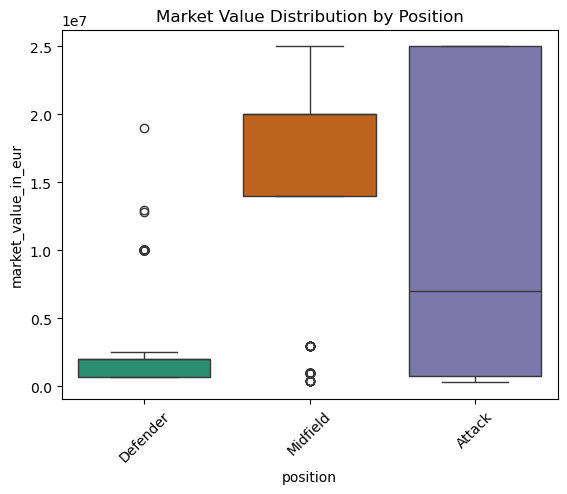

In [294]:
sns.boxplot(data=football_df, x='position', y='market_value_in_eur', palette='Dark2')
plt.title('Market Value Distribution by Position')
plt.xticks(rotation=45)
plt.show()

#####  Interpretation :
* Midfielder indicates a median significantly higher than the other two groups.Their values are also tightly grouped compared to Attackers.
* Attackers : show the widest range in market value,indicating high variability,the highest market value overall.
* Defenders have the lowest overall market value ,the both median and upper quartile significantly lower than Midfielders and Attackers.
* Outliers:Several outliers are present in each group especially among Midfielders and Defenders.

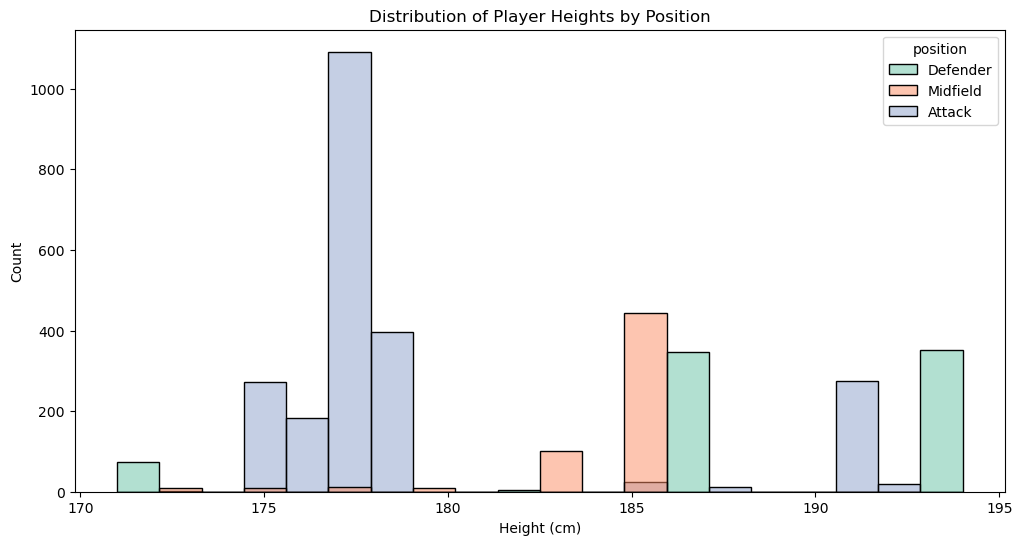

In [296]:
plt.figure(figsize=(12,6))
sns.histplot(data=football_df, x='height_in_cm', hue='position', palette='Set2', bins=20)
plt.title('Distribution of Player Heights by Position')
plt.xlabel('Height (cm)')
plt.ylabel('Count')
plt.show()

* Interpretation :The chart supports common football trends that defenders tend to be taller, attackers shorter and quicker, and midfielders fall somewhere in between.

######

------------------------

##### K-means Clustering
* Can we cluster players based on their  attributes and performance stats (e.g., position_n, goals, assists, foot_n)?


In [301]:
football_df.columns

Index(['appearance_id', 'player_id', 'yellow_cards', 'red_cards', 'goals',
       'assists', 'minutes_played', 'season', 'round', 'home_club_goals',
       'away_club_goals', 'home_club_position', 'away_club_position',
       'home_club_manager_name', 'away_club_manager_name', 'stadium',
       'attendance', 'referee', 'home_club_name', 'away_club_name',
       'aggregate', 'competition_type', 'game_event_id', 'date', 'minute',
       'event_type', 'player_in_id', 'player_assist_id', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'date_of_birth',
       'sub_position', 'position', 'foot', 'height_in_cm',
       'market_value_in_eur', 'highest_market_value_in_eur',
       'contract_expiration_date', 'game_lineups_id', 'player_role', 'number',
       'team_captain', 'player_sub_position', 'player_name', 'game_id',
       'total_contributions', 'yellow_cards_c', 'total_goals', 'foot_n',
       'country_of_birth_n', 'player_sub_position_n', 'position_n'

In [302]:
feature_kmeans = football_df[['height_in_cm','market_value_in_eur','player_sub_position_n']]# competetion ,goals, assists.
feature_kmeans

,height_in_cm,market_value_in_eur,player_sub_position_n
0,186.0,700000.0,9
1,186.0,700000.0,9
2,186.0,700000.0,9
3,186.0,700000.0,9
4,186.0,700000.0,9
...,...,...,...
3632,176.0,300000.0,3
3633,176.0,300000.0,3
3634,176.0,300000.0,3
3635,176.0,300000.0,3


##### Performing Data Sacling to avoid the baised value 

In [304]:
scaler = StandardScaler()
cols = feature_kmeans.columns 
df_scaled_kmeans = scaler.fit_transform(feature_kmeans)
df_scaled_kmeans = pd.DataFrame(df_scaled_kmeans,columns = cols)
df_scaled_kmeans

,height_in_cm,market_value_in_eur,player_sub_position_n
0,0.679979,-1.004730,1.158142
1,0.679979,-1.004730,1.158142
2,0.679979,-1.004730,1.158142
3,0.679979,-1.004730,1.158142
4,0.679979,-1.004730,1.158142
...,...,...,...
3632,-0.882692,-1.041634,-1.008236
3633,-0.882692,-1.041634,-1.008236
3634,-0.882692,-1.041634,-1.008236
3635,-0.882692,-1.041634,-1.008236


In [305]:
# minmax the values can be 0 to 1 ,also the value can less than 0 .The minmax scaler is very sensitive to  the outliers that why it's no recommended 

##### Finding the k value through elbow curve 

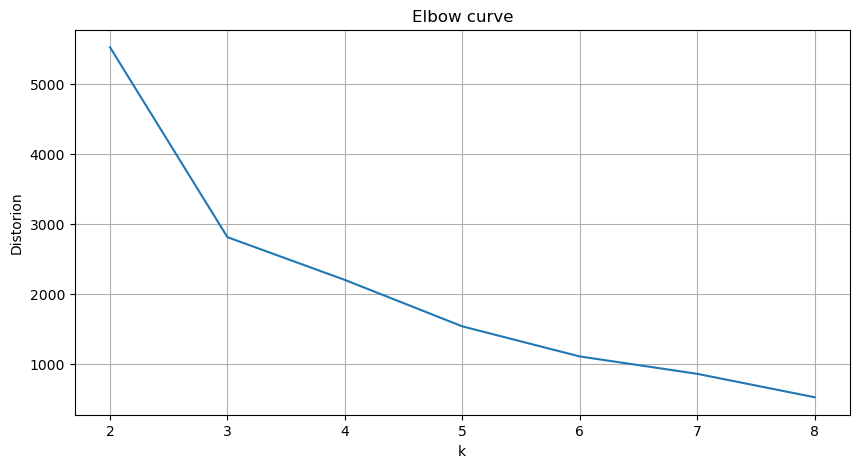

In [307]:
distorion = []
for k in range(2,9):
    kmeans = KMeans(n_clusters = k,random_state = 7)
    kmeans.fit(df_scaled_kmeans)
    distorion.append(kmeans.inertia_)
fig = plt.figure(figsize = (10,5))
plt.plot(range(2,9),distorion)
plt.grid(True)
plt.xlabel('k')
plt.ylabel('Distorion')
plt.title('Elbow curve')
plt.show()

##### The "elbow" appears at k = 3, where the rate of distortion reduction slows down significantly. This suggests that grouping players into 4 clusters is a good balance between accuracy and simplicity.



For n_clusters = 2 The average silhouette_score is : 0.4466281061964144
For n_clusters = 3 The average silhouette_score is : 0.614068211543377
For n_clusters = 4 The average silhouette_score is : 0.633711317697148
For n_clusters = 5 The average silhouette_score is : 0.6603313964746323
For n_clusters = 6 The average silhouette_score is : 0.7037708077578921


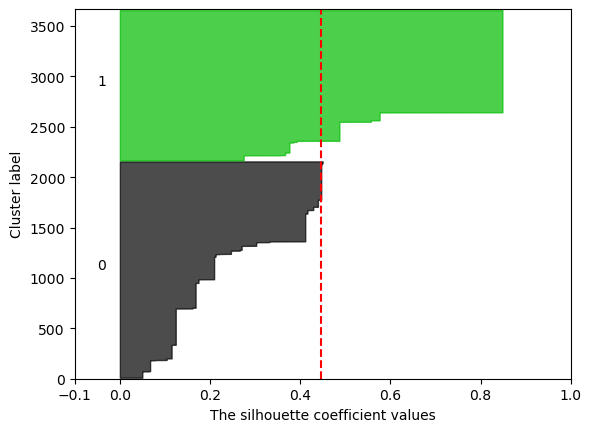

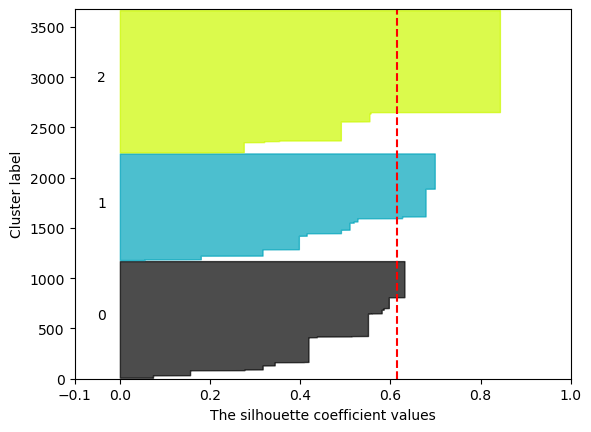

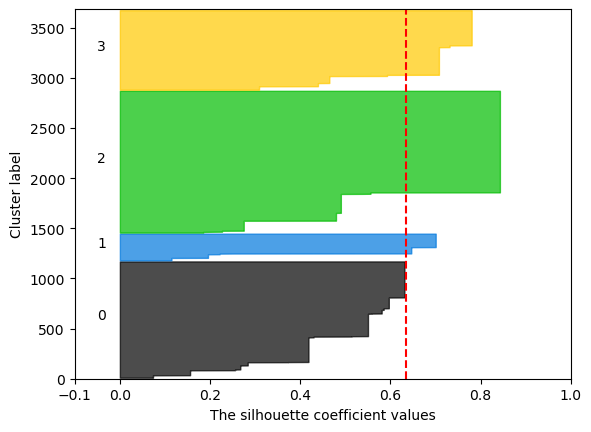

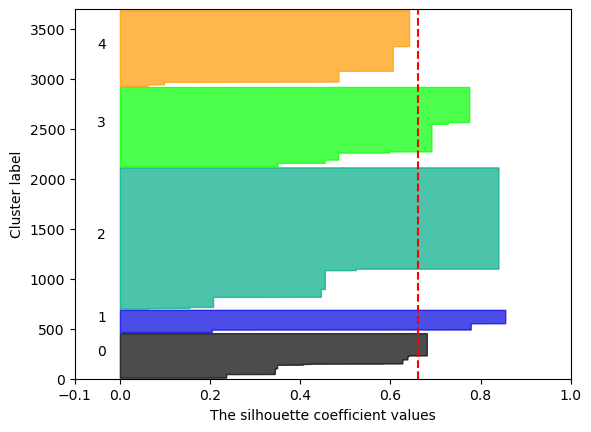

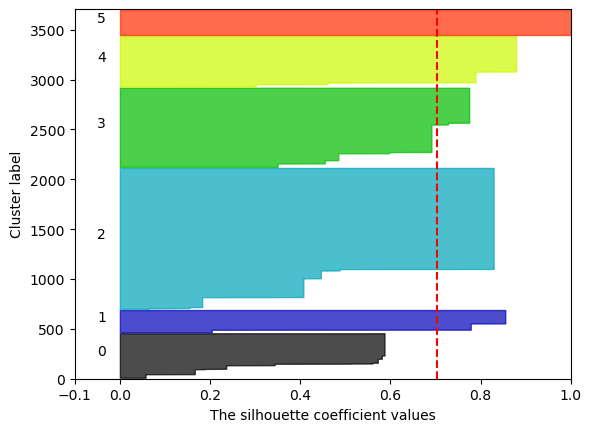

In [309]:
import numpy as np
range_n_clusters = [2, 3, 4, 5, 6]
for n_clusters in range_n_clusters:
    fig, ax1 = plt.subplots(1, 1) # Create a subplot with 1 row and 1 columns
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(df_scaled_kmeans) + (n_clusters + 1)*10])
    # initializeing and  training the KMeans model
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    cluster_labels = clusterer.fit_predict(df_scaled_kmeans)
    silhouette_avg = silhouette_score(df_scaled_kmeans, cluster_labels)
    print("For n_clusters =", n_clusters,
    "The average silhouette_score is :", silhouette_avg)
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(df_scaled_kmeans, cluster_labels)
    # vizuavalizing silhoutee score for each clusters
    y_lower = 10# initialize the starting y position for plottting the silhouette score for the first cluster.
    for i in range(n_clusters):#loop iterates through each cluster from 0 to n_clusters-1.
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]# select the silhoutee score for all data points belong to the cluster i.
        ith_cluster_silhouette_values.sort()# sort the silhoute score of hte current cluster in ascending order.
        size_cluster_i = ith_cluster_silhouette_values.shape[0]# get the number of data points in the current clusters.
        y_upper = y_lower + size_cluster_i#calculate the upper position for plotitng the silhoute score for the current cluster.
        color = cm.nipy_spectral(float(i) / n_clusters)# assign a unique colur to the current clusters using the nipy_spectral color map.The color is determined by the cluster index i relative to the no of clusters.
        ax1.fill_betweenx(np.arange(y_lower, y_upper),0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)# create a filled area plot representin the silhoute score of the current plot. nparange:generate an array o f the y values of the current cliusters.0:the starting x value s ath the silhouete score of 0.ith cluster silhoute  values:the x values (the silhouete scores) tha tdefines the width of the filled areea.
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))# add a text label indicating the cluster no in the y axis.
        y_lower = y_upper + 10 # update the starting y position for the next clusters adding some vertical spacing.
    #setting plot labels
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")# draws a vertical dashed red line at the avg silhoute score for the current no of clusters.This helps to vizualize the overall quality of clustering. 
    #ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8,1])
plt.show()

In [310]:
# The  score is for 3 clusters (0.61), indicating that this may be the best fit among the tested values. 

In [311]:
# step 1: create the model 
KMeans_model_3 = KMeans(n_clusters = 3,random_state = 1)

In [312]:
# step 2: fitting the model 
KMeans_model_3.fit(df_scaled_kmeans)

KMeans(n_clusters=3, random_state=1)

In [313]:
# step 3 find the centroid 
cluster_centroid_3 = KMeans_model_3.cluster_centers_
cluster_centroid_3 

array([[-0.54054659, -0.95555583,  0.47675571],
       [ 1.22521993, -0.41957569, -1.38495349],
       [-0.47518287,  1.09863613,  0.64729489]])

In [314]:
df_scaled_kmeans

,height_in_cm,market_value_in_eur,player_sub_position_n
0,0.679979,-1.004730,1.158142
1,0.679979,-1.004730,1.158142
2,0.679979,-1.004730,1.158142
3,0.679979,-1.004730,1.158142
4,0.679979,-1.004730,1.158142
...,...,...,...
3632,-0.882692,-1.041634,-1.008236
3633,-0.882692,-1.041634,-1.008236
3634,-0.882692,-1.041634,-1.008236
3635,-0.882692,-1.041634,-1.008236


In [315]:
# finding the six labels
labels_3 = KMeans_model_3.labels_
labels_3

array([0, 0, 0, ..., 0, 0, 0])

* plotting this with two feature

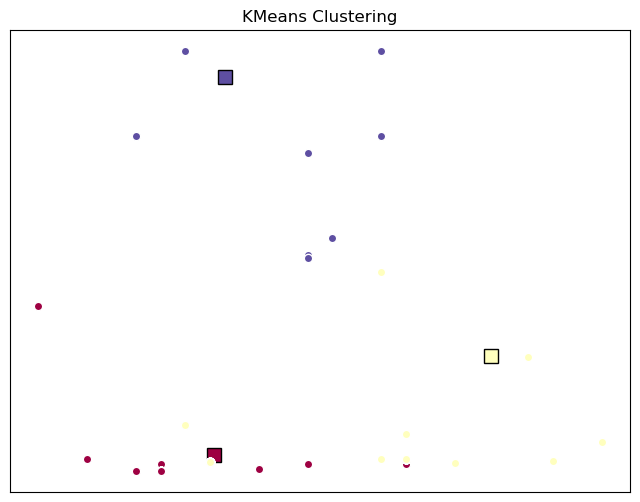

In [324]:
import matplotlib.pyplot as plt
import numpy as np

# Convert DataFrame to NumPy array
df_array = df_scaled_kmeans.values
unique_labels = np.unique(labels_3) # labels_4 : contains the predicted cluster label (e.g. 0, 1, 2, 3) for each point after applying KMeans.
                                    # np.unique: returns the distinct cluster labels.
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels))) # generates a range of colors spaced evenly for each cluster label.

fig = plt.figure(figsize=(8, 6)) # creates a new plot with a size of 8x6 inches.
ax = fig.add_subplot(1, 1, 1) # adds one subplot (just 1 row, 1 column, 1 plot area).

for k, col in zip(unique_labels, colors): # loops over each cluster index k and its corresponding color col.
    my_member = (labels_3 == k) # creates a boolean array selecting data points in cluster k
    cluster_centroid = cluster_centroid_3[k] #  retrieves the centroid coordinates of cluster k.

    ax.plot(df_array[my_member, 0], df_array[my_member, 1], 'w', # df_array[my_member, 0]:  Feature 1 ,df_array[my_member, 1]:  Feature 2 
            markerfacecolor=col, marker='o', linestyle='None') # markerfacecolor=col: fills the dot with its cluster color.
    
    ax.plot(cluster_centroid[0], cluster_centroid[1], 'w', #  markerfacecolor=col : matches the color of the cluster.
            markerfacecolor=col, marker='s', markersize=10, markeredgecolor='k') # markeredgecolor='k' → black border around the centroid square for visibility.

ax.set_xticks(())
ax.set_yticks(())
ax.set_title('KMeans Clustering')
plt.show()


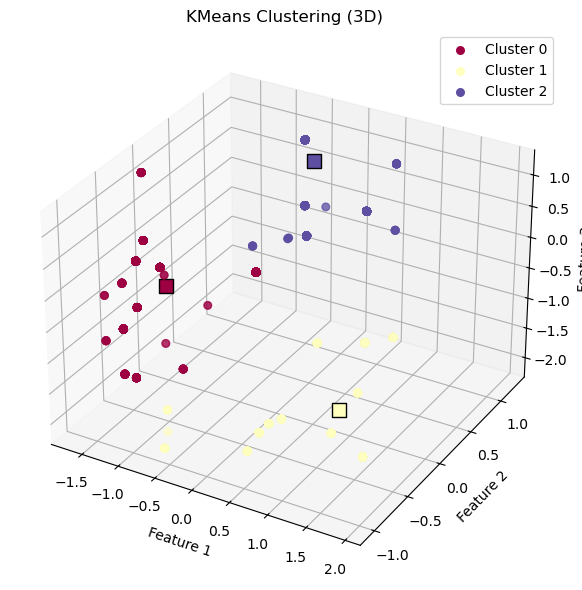

In [328]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plots, Axes3D: enables 3D plotting with matplotlib.



# Convert DataFrame to NumPy array
df_array = df_scaled_kmeans.values
unique_labels = np.unique(labels_3)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

# Create 3D figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d') # add_subplot(111, projection='3d'): Creates a single 3D subplot.

# Loop through clusters
for k, col in zip(unique_labels, colors):
    my_member = (labels_3 == k)
    cluster_centroid = cluster_centroid_3[k]

    ax.scatter(df_array[my_member, 0],  # X (feature 1)
               df_array[my_member, 1],  # Y (feature 2)
               df_array[my_member, 2],  # Z (feature 3)
               c=[col], label=f'Cluster {k}', s=30)

    # Plot centroids
    ax.scatter(cluster_centroid[0], cluster_centroid[1], cluster_centroid[2],
               marker='s', c=[col], edgecolor='k', s=100)

# Set labels and title
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('KMeans Clustering (3D)')
ax.legend()
plt.tight_layout()
plt.show()

In [330]:
from sklearn.metrics import calinski_harabasz_score
chi_index=calinski_harabasz_score(df_scaled_kmeans,labels_3)
round(chi_index,2)

5231.04

In [332]:
 # A higher score indicates dense and well-separated clusters ,better clustering performance.

In [334]:
from sklearn.metrics import davies_bouldin_score
db_score=davies_bouldin_score(df_scaled_kmeans,labels_3)
round(db_score,3)

0.677

In [336]:
# A Davies-Bouldin Score of 0.60 is fairly good, indicating that your clusters are reasonably compact and distinct from one another

In [338]:
silhouete_avg=silhouette_score(df_scaled_kmeans,labels_3)
round(silhouete_avg,3)

0.614

In [ ]:
# Moderately high score ,most points are well-matched to their own cluster and reasonably far from neighboring clusters

* The clustering model shows strong performance with compact and well-separated clusters based on physical and performance stats.

* These metrics validate that players can be meaningfully grouped for analysis or strategy using unsupervised learning

### Contract Management
------------------------------
##### Descriptive Analysis & Visualization
* How many players have contracts expiring in each upcoming year, and what is the distribution across clubs?
* What is the trend of upcoming contract expirations over time?


##### Done the visualization in tableau

================================================================
------------------------

================================================================
------------------------

--------------------------------